## EEG 睡眠分期数据预处理


1. 导入库 配置参数
1. 定义睡眠阶段映射字典：建立睡眠阶段到数值标签映射
1. 实现单患者数据处理函数def
1. 扫描并匹配 PSG 和 Hypnogram 
1. 并行处理患者数据： joblib 并行执行处理函数
1. 过滤并批量合并数据
1. 使用过采样平衡类别
1. 输出最终统计

### 过程1

尝试对edf文件，使用mne库进行读入psg，一一对应其hypnogram标注文件

处理后数据存储在变量`X_resampled`（展平的特征数据）; `y_resampled` （标签）

最终将处理好的以上俩数据保存至npy

In [ ]:
# EEG 睡眠分期数据处理脚本，用于 Sleep-EDF 数据集
# 此脚本负责从 PSG (多导睡眠图) 和 Hypnogram (睡眠图) 文件中加载 EEG 数据，
# 处理成固定时长的 epochs，并通过过采样平衡类别。
# 它具有健壮的错误处理能力，能跳过无效文件/患者，使用缓存提高效率。
# 所需库：mne (用于EEG数据处理), numpy (数值计算), imblearn (处理不平衡数据),
# joblib (并行处理和缓存), tqdm (显示进度条), pyedflib (通过mne安装)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)  # 抑制所有RuntimeWarning（如filter警告）
import mne
mne.set_log_level('WARNING')  # 全局设置MNE日志级别为WARNING，只显示警告和错误，不显示INFO（包括rejection打印）

import numpy as np
import os
import glob
from imblearn.over_sampling import RandomOverSampler
import joblib
from tqdm import tqdm
from collections import Counter
import gc # Python垃圾回收机制，用于手动清理内存

# --- 配置部分 ---
base_path = r'./sleep-edf/data/train'  # 调整为数据集根路径  r''表示原始字符串，避免路径中的反斜杠被解释为转义字符。
cache_dir = os.path.join(base_path, 'cache') # 定义缓存目录，用于存储已处理的数据
os.makedirs(cache_dir, exist_ok=True) # 如果缓存目录不存在则创建它。exist_ok=True表示如果目录已存在则不报错。

n_jobs = 1  # 并行处理的CPU核心数。
            # 设为 1 表示串行处理（不使用并行），如果并行处理遇到问题可以尝试。
            # 通常设为 2 或更多（例如 -1 表示使用所有可用核心）可以加速处理。
worker_timeout = 600  # 每个并行任务的超时时间（秒）。如果某个任务处理时间过长，它将被中止。
                      # 如果数据量大或处理复杂，可能需要调高此值。
subset_patients = None  # 用于调试或测试的小部分患者ID列表。
                        # 例如：['SC4001', 'SC4002']。设为 None 则处理所有找到的患者。

# 睡眠阶段映射字典
# 将原始的睡眠阶段描述（字符串）映射为数值标签。
# 这是机器学习模型训练时需要的格式。
stage_dict = {
    'Sleep stage W': 0, # W代表清醒 (Wake)
    'Sleep stage 1': 1, # N1睡眠
    'Sleep stage 2': 2, # N2睡眠
    'Sleep stage 3': 3, # N3睡眠 (深睡眠)
    'Sleep stage 4': 3, # Sleep-EDF原始数据通常有N3和N4，现代标准常将它们合并为N3。
                         # 这里将其与'Sleep stage 3'合并，都映射为标签 3。
    'Sleep stage R': 4, # REM睡眠
    'Sleep stage ?': -1, # 未知或未分类的睡眠阶段。通常会跳过这些数据。
    'W': 0, 'w': 0,      # 数据集中可能存在简化的标注形式 进行扩展
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 3,              # 同样，简化的N4也合并到N3
    'R': 4, 'r': 4,
}


def process_single_patient(patient_id, psg_file, annot_file):
    """
    处理单个患者的 EEG 数据：加载、重采样、提取 epochs ，并进行缓存。
    这个函数是整个数据处理的核心逻辑。
    参数：
        patient_id (str): 患者的唯一ID（例如 'SC4001'）。
        psg_file (str): PSG 数据文件的完整路径。
        annot_file (str): 睡眠分期标注文件的完整路径。
    返回：
        (X_epoch, y_epoch) 或 None：如果处理成功，返回一个元组，其中 X_epoch 是 EEG epochs 数据，
                                     y_epoch 是对应的睡眠阶段标签。如果处理失败、文件无效或被跳过，则返回 None。
    """
    # --- 1. 检查缓存 ---
    cache_x_path = os.path.join(cache_dir, f"{patient_id}_X.npy") # 患者EEG数据缓存路径
    cache_y_path = os.path.join(cache_dir, f"{patient_id}_y.npy") # 患者标签数据缓存路径
    
    if os.path.exists(cache_x_path) and os.path.exists(cache_y_path):
        # 如果缓存文件已存在，则直接从缓存加载，避免重复处理，提高效率。
        print(f"Loading cached {patient_id}")
        return np.load(cache_x_path), np.load(cache_y_path)
    
    # --- 2. 前置检查 ---
    # 如果标注文件不存在，则不能进行睡眠分期，直接跳过该患者。
    if not os.path.exists(annot_file):
        print(f"Missing annotation for {patient_id}, skipping")
        return None
    
    try:
        # --- 3. 加载原始数据和标注 ---
        # mne.io.read_raw_edf() 用于加载 EDF 格式的脑电数据。
        # preload=True 表示将所有数据加载到内存中，便于后续处理。
        # verbose=False 抑制冗余输出。
        raw = mne.io.read_raw_edf(psg_file, preload=True, verbose=False)
        # mne.read_annotations() 用于加载睡眠分期标注。
        annot = mne.read_annotations(annot_file)
        # 清理标注描述：移除描述字符串两端的空白字符，确保与stage_dict中的键精确匹配。
        annot.description = [d.strip() for d in annot.description]
        
        # --- 4. 通道选择和重采样 ---
        # 挑选 'EEG Fpz-Cz' 通道数据。这是MNE处理EEG数据时常用的参考电极。
        # 在睡眠研究中，一些标准方法可能只使用一个或少数几个EEG通道进行分期。
        raw.pick_channels(['EEG Fpz-Cz'])
        # 将数据重采样到 100 Hz。这将减少数据点数量，降低计算复杂性，
        # 并使所有患者的数据具有相同的采样率。30秒的epoch将变为30 * 100 = 3000个采样点。
        raw.resample(100)
        
        # --- 5. 将标注应用到原始数据 ---
        # 必须在事件提取之前将标注设置到 raw 对象中。
        raw.set_annotations(annot)

        # --- 6. 从标注中提取事件 ---
        # mne.events_from_annotations() 根据 raw 对象中的标注，结合 stage_dict，
        # 提取出事件（即睡眠阶段变化的起始点）。
        # events 是一个 N x 3 的 NumPy 数组，其中 N 是事件数量，
        # 第二列是采样点索引，第三列是事件ID（对应stage_dict中的值）。
        # event_id 是一个字典，将原始的睡眠阶段描述映射到对应的数值ID。
        events, event_id = mne.events_from_annotations(raw, stage_dict, verbose=False)
        
        # 如果没有提取到任何有效事件（例如，标注文件与 stage_dict 不匹配，或者文件损坏），则跳过。
        if len(events) == 0:
            print(f"No valid events for {patient_id} (check annotations: {set(annot.description[:5])}), skipping")
            return None
        
        # --- 7. 创建 Epochs ---
        # mne.Epochs() 用于将连续的原始数据切分成固定长度的 epochs。
        # raw: 输入的原始数据。
        # events, event_id: 从标注中提取的事件和其对应的ID。
        # tmin=0, tmax=30: 每个 epochs 的起始和结束时间（相对于事件发生点），这里表示每个 epochs 从事件点开始持续 30 秒。
        # baseline=None: 不进行基线校正。
        # verbose=False: 抑制冗余输出。
        # on_missing='ignore': 如果事件 ID 在 event_id 中不存在，则忽略该事件。
        epoques = mne.Epochs(raw, events, event_id, tmin=0, tmax=30, baseline=None, verbose=False, on_missing='ignore')

        # --- 8. 丢弃坏 epochs (Drop Bad Epochs) ---
        # 根据振幅阈值丢弃不符合质量标准的 epochs。
        # reject=dict(eeg=150e-6): 如果 EEG 通道的数据峰峰值超过 150微伏 (μV)，则认为该 epochs 是坏的。
        # flat=dict(eeg=0.5e-6): 如果 EEG 通道的数据在 30 秒内变化小于 0.5微伏，则认为该 epochs 是平坦的（可能死机或连接脱落）。
        # 这些阈值需要根据数据的具体情况进行调整。
        epoques.drop_bad(reject=dict(eeg=150e-6), flat=dict(eeg=0.5e-6))
        
        # 如果丢弃所有坏 epochs 后，没有剩下任何有效 epochs，则跳过该患者。
        if len(epoques) == 0:
            print(f"No valid epochs after drop_bad for {patient_id}, skipping")
            return None
        
        # --- 9. 获取 epochs 数据和标签 ---
        # epoques.get_data() 提取所有有效 epochs 的数据。
        # 形状通常是 (n_epochs, n_channels, n_samples)，例如 (200, 1, 3000)。
        X_epoch = epoques.get_data()
        # epoques.events[:, 2] 提取每个 epochs 对应的事件ID，也就是睡眠阶段的数值标签。
        y_epoch = epoques.events[:, 2]
        
        # --- 10. 保存到缓存 ---
        # 将处理好的数据和标签保存为 NumPy 的 .npy 文件，以便下次直接加载，提高效率。
        np.save(cache_x_path, X_epoch)
        np.save(cache_y_path, y_epoch)
        print(f"Processed {patient_id}: {X_epoch.shape[0]} epochs")
        
        # 强制进行垃圾回收，释放不再使用的内存（尤其是MNE对象可能会占用较多内存）。
        gc.collect()
        return X_epoch, y_epoch
    
    except Exception as e:
        # 捕获并打印处理过程中发生的任何错误，避免程序崩溃，并跳过有问题的患者。
        print(f"Error processing {patient_id}: {str(e)}")
        gc.collect()
        return None

# --- 主程序执行部分 ---
if __name__ == "__main__":
    # --- 1. 扫描和匹配 PSG 和 Hypnogram 文件 ---
    # 使用 glob 查找所有以 '-PSG.edf' 结尾的 PSG 文件。
    psg_files = glob.glob(os.path.join(base_path, '*-PSG.edf'))
    # 使用 glob 查找所有以 '-Hypnogram.edf' 结尾的 Hypnogram 文件。
    hyp_files = glob.glob(os.path.join(base_path, '*-Hypnogram.edf'))
    
    # 构建一个字典来存储每个患者的 PSG 和 Hypnogram 文件路径，确保它们是配对的。
    patient_dict = {}
    for psg in psg_files:
        # 从文件名中提取患者ID (例如 'SC4001E0-PSG.edf' -> 'SC4001E0')
        # 这里假设患者ID是文件名前6个字符。需要根据实际文件名格式调整。
        patient_id = os.path.basename(psg)[:6] 
        patient_dict[patient_id] = {'psg': psg, 'hyp': None} # 初始化 Hypnogram 为 None
    for hyp in hyp_files:
        patient_id = os.path.basename(hyp)[:6]
        if patient_id in patient_dict: # 如果找到对应的 PSG 文件，则更新 Hypnogram 路径
            patient_dict[patient_id]['hyp'] = hyp
    
    # 过滤出所有同时拥有 PSG 和 Hypnogram 文件的有效患者。
    valid_patients = [(pid, data['psg'], data['hyp']) for pid, data in patient_dict.items() if data['hyp']]
    
    # 如果指定了子集患者，则只处理这些患者。
    if subset_patients:
        valid_patients = [p for p in valid_patients if p[0] in subset_patients]
    
    print(f"Found {len(valid_patients)} valid patients to process")
    
    # --- 2. 并行处理患者数据 ---
    # joblib.Parallel 用于并行执行函数调用。
    # n_jobs: 并行进程/线程数。
    # backend='loky': 推荐用于CPU密集型任务的后端，因为它更加健壮。
    # timeout: 每个任务的超时时间。
    # verbose: 控制进度信息的输出级别。
    # joblib.delayed() 包装函数调用，使其可以被并行执行。
    # tqdm(valid_patients, desc="Processing patients") 提供了一个美观的进度条。
    results = joblib.Parallel(n_jobs=n_jobs, backend='loky', timeout=worker_timeout, verbose=10)(
        joblib.delayed(process_single_patient)(*pat) for pat in tqdm(valid_patients, desc="Processing patients")
    )
    
    # --- 3. 过滤有效结果并合并数据 ---
    # 过滤掉 `process_single_patient` 函数返回的 None 结果（即处理失败或跳过的患者）。
    results = [r for r in results if r is not None]
    if not results:
        # 如果没有任何患者被成功处理，则抛出错误。
        raise ValueError("No patients were successfully processed. Check data files or annotations.")
    
    # 将所有患者的 EEG epochs数据和标签分别收集到两个列表中。
    X_list = [r[0] for r in results] # 包含每个患者的 EEG epochs 数据的 NumPy 数组列表
    y_list = [r[1] for r in results] # 包含每个患者的睡眠阶段标签的 NumPy 数组列表
    
    # --- 4. 批量合并数据以避免内存问题 ---
    # 如果简单地对所有 X_list 和 y_list 中的 NumPy 数组进行 np.concatenate()，
    # 当数据量巨大时，可能会导致内存溢出。
    # 这个辅助函数将数据分批合并，每次只处理一小批数据，然后将批次结果合并，以节省内存。
    def merge_batches(data_list, batch_size=50):
        merged = []
        for i in range(0, len(data_list), batch_size):
            batch = data_list[i:i + batch_size] # 取一个批次的数据
            if batch: # 确保批次不为空
                merged.append(np.concatenate(batch, axis=0)) # 合并批次中的所有数组
        # 最后将所有批次合并的结果数组拼接起来。
        return np.concatenate(merged, axis=0) if merged else np.array([])
    
    X = merge_batches(X_list) # 合并所有患者的 EEG epochs 数据
    y = merge_batches(y_list) # 合并所有患者的睡眠阶段标签
    
    print(f"Merged data shape: {X.shape}, Unique labels: {np.unique(y)}")
    
    # --- 5. 使用过采样平衡类别 ---
    # 预先定义过采样后的数据缓存路径。
    final_X_path = os.path.join(cache_dir, 'X_resampled.npy')
    final_y_path = os.path.join(cache_dir, 'y_resampled.npy')
    
    if os.path.exists(final_X_path) and os.path.exists(final_y_path):
        # 如果过采样后的数据已在缓存中，直接加载。
        print("Loading pre-computed balanced data")
        X_resampled = np.load(final_X_path)
        y_resampled = np.load(final_y_path)
    else:
        print("Balancing dataset...")
        # 打印原始数据集的类别分布，以便观察不平衡情况。
        print("Original label distribution:", Counter(y))
        
        # RandomOverSampler 要求输入数据是二维的 (n_samples, n_features)。
        # X 数据形状是 (n_epochs, n_channels, n_samples_in_epoch)，例如 (N, 1, 3000)。
        # 所以需要将其展平为 (N, 3000)。
        X_flat = X.reshape(X.shape[0], -1) 
        
        # 初始化随机过采样器。random_state 确保每次运行结果可复现。
        ros = RandomOverSampler(random_state=42)
        
        # 对展平的特征数据 X_flat 和标签 y 进行过采样。
        # 它会复制少数类别的样本，直到各个类别的样本数量大致相等。
        X_resampled, y_resampled = ros.fit_resample(X_flat, y)
        
        # 将过采样后的特征数据重新整形回原始的epochs形状 (n_epochs, n_channels, n_samples_in_epoch)。
        # -1 让 NumPy 自动计算第一个维度的大小。
        X_resampled = X_resampled.reshape(-1, X.shape[1], X.shape[2])
        
        # 将平衡后的数据保存到缓存。
        np.save(final_X_path, X_resampled)
        np.save(final_y_path, y_resampled)
    
    print(f"Balanced data shape: {X_resampled.shape}, New distribution: {Counter(y_resampled)}")
    print("数据处理完成。已准备好进行模型训练。")



Found 122 valid patients to process


Processing patients:   0%|          | 0/122 [00:00<?, ?it/s]d:\Learning\Year4\a\gp\EEG_Sleep_AI\venv1\lib\site-packages\joblib\parallel.py:1383: UserWarning: The backend class 'SequentialBackend' does not support timeout. You have set 'timeout=600' in Parallel but the 'timeout' parameter will not be used.
  warnings.warn(
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    2.1s
Processing patients:   1%|          | 1/122 [00:02<04:28,  2.22s/it]

Processed SC4001: 59 epochs


Processing patients:   2%|▏         | 2/122 [00:05<05:17,  2.65s/it]

Processed SC4011: 91 epochs


...

Processed SC4812: 52 epochs


Processing patients: 100%|██████████| 122/122 [03:41<00:00,  1.81s/it]

Processed SC4822: 42 epochs
Merged data shape: (11307, 1, 3001), Unique labels: [-1  0  1  2  3  4]
Balancing dataset...
Original label distribution: Counter({np.int64(2): 3824, np.int64(1): 3771, np.int64(3): 1300, np.int64(0): 1279, np.int64(4): 1112, np.int64(-1): 21})



[Parallel(n_jobs=1)]: Done 122 out of 122 | elapsed:  3.7min finished


Balanced data shape: (22944, 1, 3001), New distribution: Counter({np.int64(1): 3824, np.int64(2): 3824, np.int64(3): 3824, np.int64(4): 3824, np.int64(0): 3824, np.int64(-1): 3824})
数据处理完成。已准备好进行模型训练。


## 过程2

考虑对数据进行8:1:1划分(训练集，验证集，测试集)

在split中完成复制处理后，此处完成整合处理

加入检查点机制保存每个患者的独一份数据



In [ ]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import mne
mne.set_log_level('WARNING')

import numpy as np
import os
import glob
from imblearn.over_sampling import RandomOverSampler
import joblib
from tqdm import tqdm
from collections import Counter
import gc

# --- 配置部分 ---
# 定义要处理的文件夹：字典键是 "类型" (train/val/test)，值是文件夹路径
folder_configs = {
    'train': r'./sleep-edf/data/train',  # 平衡=True
    'val': r'./sleep-edf/data/val',      # 平衡=True
    'test': r'./sleep-edf/data/test'     # 平衡=False
}

n_jobs = 1  # 并行核心数（1 代表串行，稳定性高）
worker_timeout = 600  # 超时秒数
subset_patients = None  # 调试用：如 ['SC4001']，设 None 处理全部
cleanup_cache = False  # 是否在 resampled 生成后清理病人级缓存（*.npy）

# 睡眠阶段映射
stage_dict = {
    'Sleep stage W': 0,
    'Sleep stage 1': 1,
    'Sleep stage 2': 2,
    'Sleep stage 3': 3,
    'Sleep stage 4': 3,
    'Sleep stage R': 4,
    'Sleep stage ?': -1,
    'W': 0, 'w': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 3,
    'R': 4, 'r': 4,
}

def process_single_patient(patient_id, psg_file, annot_file):
    """处理单个病人的数据"""
    cache_x_path = os.path.join(cache_dir, f"{patient_id}_X.npy")
    cache_y_path = os.path.join(cache_dir, f"{patient_id}_y.npy")
    
    if os.path.exists(cache_x_path) and os.path.exists(cache_y_path):
        print(f"Loading cached {patient_id}")
        return np.load(cache_x_path), np.load(cache_y_path)
    
    if not os.path.exists(annot_file):
        print(f"Missing annotation for {patient_id}, skipping")
        return None
    
    try:
        raw = mne.io.read_raw_edf(psg_file, preload=True, verbose=False)
        annot = mne.read_annotations(annot_file)
        annot.description = [d.strip() for d in annot.description]
        
        raw.pick_channels(['EEG Fpz-Cz'])
        raw.resample(100)
        
        raw.set_annotations(annot)
        events, event_id = mne.events_from_annotations(raw, stage_dict, verbose=False)
        
        if len(events) == 0:
            print(f"No valid events for {patient_id}, skipping")
            return None
        
        epoques = mne.Epochs(raw, events, event_id, tmin=0, tmax=30, baseline=None, verbose=False, on_missing='ignore')
        epoques.drop_bad(reject=dict(eeg=150e-6), flat=dict(eeg=0.5e-6))
        
        if len(epoques) == 0:
            print(f"No valid epochs for {patient_id}, skipping")
            return None
        
        X_epoch = epoques.get_data()
        y_epoch = epoques.events[:, 2]
        
        np.save(cache_x_path, X_epoch)
        np.save(cache_y_path, y_epoch)
        print(f"Processed {patient_id}: {X_epoch.shape[0]} epochs")
        gc.collect()
        return X_epoch, y_epoch
    
    except Exception as e:
        print(f"Error processing {patient_id}: {e}")
        gc.collect()
        return None

def merge_batches(data_list, batch_size=50):
    """分批合并数据"""
    merged = []
    for i in range(0, len(data_list), batch_size):
        batch = data_list[i:i + batch_size]
        if batch:
            merged.append(np.concatenate(batch, axis=0))
    return np.concatenate(merged, axis=0) if merged else np.array([])

def balance_and_save(X, y, final_X_path, final_y_path):
    """平衡数据（过采样），并保存"""
    if os.path.exists(final_X_path) and os.path.exists(final_y_path):
        print("Loading pre-computed balanced data")
        return np.load(final_X_path), np.load(final_y_path)
    
    print("Balancing dataset...")
    print("Original label distribution:", Counter(y))
    
    X_flat = X.reshape(X.shape[0], -1)
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_flat, y)
    X_resampled = X_resampled.reshape(-1, X.shape[1], X.shape[2])
    
    np.save(final_X_path, X_resampled)
    np.save(final_y_path, y_resampled)
    
    return X_resampled, y_resampled

def cleanup_patient_cache(cache_dir):
    """清理病人级缓存（删除 patient_*.npy 文件）"""
    if not cleanup_cache:
        return
    pattern = "*.npy"
    for file in glob.glob(os.path.join(cache_dir, pattern)):
        if "resampled" in os.path.basename(file):  # 保留 resampled 文件
            continue
        print(f"Removing cache file: {file}")
        os.remove(file)

def process_folder(folder_path, balance=True):
    """处理单个文件夹：扫描+配对+处理+合并+平衡（如果是）+清理"""
    global cache_dir  # 全局变量，用于缓存路径（每个文件夹独立）
    cache_dir = os.path.join(folder_path, 'cache')
    os.makedirs(cache_dir, exist_ok=True)
    
    # 1. 扫描和匹配文件（与原逻辑相同）
    psg_files = glob.glob(os.path.join(folder_path, '*-PSG.edf'))
    hyp_files = glob.glob(os.path.join(folder_path, '*-Hypnogram.edf'))
    
    patient_dict = {}
    for psg in psg_files:
        patient_id = os.path.basename(psg)[:6]
        patient_dict[patient_id] = {'psg': psg, 'hyp': None}
    for hyp in hyp_files:
        patient_id = os.path.basename(hyp)[:6]
        if patient_id in patient_dict:
            patient_dict[patient_id]['hyp'] = hyp
    
    valid_patients = [(pid, data['psg'], data['hyp']) for pid, data in patient_dict.items() if data['hyp']]
    if subset_patients:
        valid_patients = [p for p in valid_patients if p[0] in subset_patients]
    
    print(f"Found {len(valid_patients)} valid patients in {os.path.basename(folder_path)}")
    
    # 2. 并行处理病人
    results = joblib.Parallel(n_jobs=n_jobs, backend='loky', timeout=worker_timeout, verbose=10)(
        joblib.delayed(process_single_patient)(*pat) for pat in tqdm(valid_patients, desc=f"Processing {os.path.basename(folder_path)}")
    )
    
    # 3. 合并数据
    results = [r for r in results if r is not None]
    if not results:
        print(f"No valid results for {os.path.basename(folder_path)}, skipping")
        return
    
    X_list = [r[0] for r in results]
    y_list = [r[1] for r in results]
    X = merge_batches(X_list)
    y = merge_batches(y_list)
    print(f"Merged data shape for {os.path.basename(folder_path)}: {X.shape}, Unique labels: {np.unique(y)}")
    
    # 4. 平衡并保存
    final_X_path = os.path.join(cache_dir, 'X_resampled.npy')
    final_y_path = os.path.join(cache_dir, 'y_resampled.npy')
    X_resampled, y_resampled = balance_and_save(X, y, final_X_path, final_y_path)
    
    # 5. 清理病人级缓存
    cleanup_patient_cache(cache_dir)
    
    print(f"Balanced data for {os.path.basename(folder_path)}: {X_resampled.shape}, Distribution: {Counter(y_resampled)}")

# --- 主函数 ---
if __name__ == "__main__":
    for folder_type, folder_path in folder_configs.items():
        # 根据类型决定是否平衡
        balance = folder_type in ['train', 'val']
        print(f"\n=== Processing {folder_type} folder ===")
        process_folder(folder_path, balance=balance)
    
    print("\nAll folders processed. Data ready for training.")



=== Processing train folder ===
Found 122 valid patients in train


d:\Learning\Year4\a\gp\EEG_Sleep_AI\venv1\lib\site-packages\joblib\parallel.py:1383: UserWarning: The backend class 'SequentialBackend' does not support timeout. You have set 'timeout=600' in Parallel but the 'timeout' parameter will not be used.
  warnings.warn(
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    1.5s


Processed SC4001: 59 epochs


Processed SC4011: 91 epochs


Processed SC4012: 137 epochs


...

Processed SC4562: 163 epochs


Processed SC4671: 177 epochs


Processing test: 100%|██████████| 16/16 [00:28<00:00,  1.81s/it]

Processed SC4741: 74 epochs
Merged data shape for test: (1556, 1, 3001), Unique labels: [0 1 2 3 4]
Balancing dataset...
Original label distribution: Counter({np.int64(2): 544, np.int64(1): 452, np.int64(3): 217, np.int64(4): 187, np.int64(0): 156})
Balanced data for test: (2720, 1, 3001), Distribution: Counter({np.int64(1): 544, np.int64(0): 544, np.int64(2): 544, np.int64(3): 544, np.int64(4): 544})

All folders processed. Data ready for training.



[Parallel(n_jobs=1)]: Done  16 out of  16 | elapsed:   28.8s finished


## 过程3

白天的 Wake 和睡眠边缘的 Wake 在生理特征、评估价值以及模型干扰上都有显著区别

波形本质不同：白天的 Wake 包含大量的伪影（Artifacts）：眨眼、身体移动、吞咽、干扰信号。而睡眠前后的 Wake（处于床上、闭眼、安静）主要是 Alpha 律动。

任务目标偏差：睡眠监测的目的是分析“睡眠结构”。白天的 Wake 样本虽然标签是 0，但它对分析睡眠质量（如入睡潜伏期、觉醒次数）没有贡献。


### 科学地剔除（Sleep Period Clipping）：
在 Sleep-EDF 中，只保留第一段非 Wake 阶段前 30 分钟和最后一段非 Wake 阶段后 30 分钟的数据。


In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import mne
mne.set_log_level('WARNING')
import numpy as np
import os
import glob
from imblearn.over_sampling import RandomOverSampler
import joblib
from tqdm import tqdm
from collections import Counter
import gc
import re
from datetime import timedelta

# --- 配置部分 ---
# 定义要处理的文件夹：字典键是 "类型" (train/val/test)，值是文件夹路径
folder_configs = {
    'train': r'./sleep-edf/data/train',  # 平衡=True
    'val': r'./sleep-edf/data/val',      # 平衡=True
    'test': r'./sleep-edf/data/test'     # 平衡=False
}

n_jobs = 1  # 并行核心数（1 代表串行，稳定性高）
worker_timeout = 600  # 超时秒数
subset_patients = None  # 调试用：如 ['SC4001']，设 None 处理全部
cleanup_cache = False  # 是否在 resampled 生成后清理病人级缓存（*.npy）

# 睡眠阶段映射
stage_dict = {
    'Sleep stage W': 0,
    'Sleep stage 1': 1,
    'Sleep stage 2': 2,
    'Sleep stage 3': 3,
    'Sleep stage 4': 3,
    'Sleep stage R': 4,
    'Sleep stage ?': -1,
    'W': 0, 'w': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 3,
    'R': 4, 'r': 4,
}

def short_stage(desc):
    s = str(desc).lower().strip()
    # 精确匹配单字符标注或包含“sleep stage X”等形式
    if re.search(r'\bw\b', s) or 'wake' in s or 'awake' in s:
        return 'W'
    if re.search(r'\br\b', s) or 'rem' in s:
        return 'R'
    if 'stage 1' in s or s in ('1', 'n1'):
        return 'N1'
    if 'stage 2' in s or s in ('2', 'n2'):
        return 'N2'
    if 'stage 3' in s or 'stage 4' in s or 'n3' in s or 'sws' in s:
        return 'N3'
    if '?' in desc or 'unknown' in desc or 'undefined' in desc: return 'IGNORE' 
    return s  # 保留原描述以便调试

def get_robust_sleep_boundaries(starts, ends, stages, total_duration_sec):
    """
    使用双指针收缩法，排除入睡前和醒来后的零星干扰，寻找主要睡眠区间。
    GAP_THRESHOLD: 判定为“非睡眠长间隔”的阈值
    MIN_SLEEP_LIMIT: 预期的最小睡眠跨度，默认6小时
    BUFFER_SEC: 在最终结果中，睡眠前后各增加的缓冲时间
    """
    # 参数定义
    GAP_THRESHOLD_FOR_BLOCK_SEPARATION = 1 * 3600  # 区分不同睡眠块的清醒间隔：1小时
    GAP_THRESHOLD_FOR_EDGE_CLEANING = 1800  # 清理块边缘的清醒间隔：30分钟
    MIN_SLEEP_BLOCK_DURATION = 3 * 3600 # 最短的有效睡眠块时长：3小时
    MIN_SLEEP_LIMIT_FOR_ROBUSTNESS = 6 * 3600 # 鲁棒性检查的最小睡眠跨度：6小时
    BUFFER_SEC = 1800 
    # 1. 过滤掉 'W' 和 'IGNORE' 阶段
    # 确保 stages 数组在外部已经被正确处理，例如 'sleep stage ?' 标记为 'IGNORE'
    valid_sleep_stage_mask = (stages != 'W') & (stages != 'IGNORE')
    
    # 获取这些有效睡眠阶段在原始 `starts` 数组中的索引
    non_w_original_indices = np.where(valid_sleep_stage_mask)[0]
    if len(non_w_original_indices) == 0:
        print("警告: 未找到任何有效的睡眠阶段 (非W且非IGNORE)。")
        return 0.0, total_duration_sec - 0.01
    # 2. 识别所有独立的睡眠块 (Sleep Blocks)
    sleep_blocks = [] # 存储每个睡眠块的 [(start_idx_in_non_w_original_indices, end_idx_in_non_w_original_indices)]
    current_block_start_idx = non_w_original_indices[0]
    
    for i in range(len(non_w_original_indices) - 1):
        idx_current = non_w_original_indices[i]
        idx_next = non_w_original_indices[i+1]
        
        # 计算当前有效睡眠阶段结束 到 下一个有效睡眠阶段开始 之间的清醒间隔
        gap = starts[idx_next] - ends[idx_current]
        
        if gap > GAP_THRESHOLD_FOR_BLOCK_SEPARATION:
            # 发现一个大间隔，这意味着一个新的睡眠块开始
            block_start = current_block_start_idx
            block_end = idx_current
            sleep_blocks.append((block_start, block_end))
            current_block_start_idx = idx_next
            
    # 添加最后一个睡眠块
    sleep_blocks.append((current_block_start_idx, non_w_original_indices[-1]))
    print(f"识别出 {len(sleep_blocks)} 个潜在睡眠块。")
    # 3. 计算每个睡眠块的持续时间并选择最长的
    longest_block = None
    max_block_duration = 0
    for block_start_orig_idx, block_end_orig_idx in sleep_blocks:
        block_onset = starts[block_start_orig_idx]
        block_offset = ends[block_end_orig_idx]
        block_duration = block_offset - block_onset
        if block_duration > max_block_duration and block_duration >= MIN_SLEEP_BLOCK_DURATION:
            max_block_duration = block_duration
            longest_block = (block_start_orig_idx, block_end_orig_idx)
    if longest_block is None:
        print(f"警告: 未找到持续时间超过 {MIN_SLEEP_BLOCK_DURATION / 3600:.1f} 小时的主要睡眠块。")
        # 如果没有找到足够长的主睡眠块，可以返回空或者整个数据的范围，取决于你的处理逻辑
        return 0.0, total_duration_sec - 0.01 
    # 4. 对选定的主睡眠块应用双指针收缩
    # 将 longest_block 的原始索引转换回其在 `non_w_original_indices` 中的相应位置
    # 这样可以兼容之前的双指针逻辑
    left_ptr_idx = np.where(non_w_original_indices == longest_block[0])[0][0]
    right_ptr_idx = np.where(non_w_original_indices == longest_block[1])[0][0]
    # 重新计算这个块的睡眠中心时间
    block_starts_for_center = starts[non_w_original_indices[left_ptr_idx:right_ptr_idx+1]]
    block_ends_for_center = ends[non_w_original_indices[left_ptr_idx:right_ptr_idx+1]]
    
    weighted_midpoints = (block_starts_for_center + block_ends_for_center) / 2
    weighted_durations = block_ends_for_center - block_starts_for_center
    if np.sum(weighted_durations) > 0:
        sleep_center_time = np.sum(weighted_midpoints * weighted_durations) / np.sum(weighted_durations)
    else:
        sleep_center_time = (block_starts_for_center[0] + block_ends_for_center[-1]) / 2
    # 执行收缩，类似于 get_robust_sleep_boundaries_v2 的逻辑
    while left_ptr_idx < right_ptr_idx:
        current_onset_candidate = starts[non_w_original_indices[left_ptr_idx]]
        current_offset_candidate = ends[non_w_original_indices[right_ptr_idx]]
        
        current_sleep_span = current_offset_candidate - current_onset_candidate
        
        if current_sleep_span <= MIN_SLEEP_LIMIT_FOR_ROBUSTNESS and (right_ptr_idx - left_ptr_idx <= 1):
            break
            
        changed = False
        
        # 左指针右移
        if left_ptr_idx + 1 <= right_ptr_idx:
            original_idx_current = non_w_original_indices[left_ptr_idx]
            original_idx_next_valid_sleep = non_w_original_indices[left_ptr_idx + 1]
            gap_duration = starts[original_idx_next_valid_sleep] - ends[original_idx_current]
            if gap_duration > GAP_THRESHOLD_FOR_EDGE_CLEANING:
                if starts[original_idx_next_valid_sleep] < sleep_center_time:
                    left_ptr_idx += 1
                    changed = True
                elif left_ptr_idx == np.where(non_w_original_indices == longest_block[0])[0][0]: # 如果是这个块的第一个有效睡眠段，允许移动
                    left_ptr_idx += 1
                    changed = True
        
        # 右指针左移
        if right_ptr_idx - 1 >= left_ptr_idx:
            original_idx_current = non_w_original_indices[right_ptr_idx]
            original_idx_prev_valid_sleep = non_w_original_indices[right_ptr_idx - 1]
            gap_duration = starts[original_idx_current] - ends[original_idx_prev_valid_sleep]
            if gap_duration > GAP_THRESHOLD_FOR_EDGE_CLEANING:
                if ends[original_idx_prev_valid_sleep] > sleep_center_time:
                    right_ptr_idx -= 1
                    changed = True
                elif right_ptr_idx == np.where(non_w_original_indices == longest_block[1])[0][0]: # 如果是这个块的最后一个有效睡眠段，允许移动
                    right_ptr_idx -= 1
                    changed = True
        
        if not changed:
            break
    final_onset = float(starts[non_w_original_indices[left_ptr_idx]])
    final_offset = float(ends[non_w_original_indices[right_ptr_idx]])
    
    final_onset = max(0.0, final_onset - BUFFER_SEC)
    final_offset = min(total_duration_sec - 0.01, final_offset + BUFFER_SEC)
        
    return final_onset, final_offset

# --- 核心处理函数 ---

def process_single_patient(patient_id, psg_file, annot_file):
    """处理单个病人的数据"""
    cache_x_path = os.path.join(cache_dir, f"{patient_id}_X.npy")
    cache_y_path = os.path.join(cache_dir, f"{patient_id}_y.npy")
    
    if os.path.exists(cache_x_path) and os.path.exists(cache_y_path):
        return np.load(cache_x_path), np.load(cache_y_path)
    
    try:
        raw = mne.io.read_raw_edf(psg_file, preload=True, verbose=False)
        total_duration_sec = raw.times[-1] 
        # 在裁剪逻辑之前，统一将 raw.annotations 的 duration 进行微调
        # 确保标注的结束时间不会超出 signal 的末端
        raw.annotations.duration[raw.annotations.onset + raw.annotations.duration > total_duration_sec] -= 0.01
        # --- 【关键补丁 1】：加载并设置标注 ---
        if os.path.exists(annot_file):
            annot = mne.read_annotations(annot_file)
            raw.set_annotations(annot)

        sfreq = raw.info['sfreq']
        total_samples = raw.n_times
        total_duration_sec = total_samples / sfreq
        
        # 提取标注信息
        ann = raw.annotations
        onsets = np.array(ann.onset, dtype=float)
        raw_durs = np.array(ann.duration, dtype=float)
        descs = np.array(ann.description, dtype=object)
        
        # 用相邻 onset 差值推导可能的 duration (针对只有 onset 没有 duration 的数据集)
        derived = np.diff(np.append(onsets, total_duration_sec))
        durs = np.where(raw_durs > 0, raw_durs, derived[:len(onsets)])

        descs = np.array(ann.description, dtype=object)
        
        # 计算 starts / ends 如前（durs 已经用 derived 填充）
        starts = onsets
        ends = starts + durs

        # 过滤：去掉 start >= total_duration，或 end <= start，或时长太短（例如 < 1s）
        valid_mask = (starts < total_duration_sec) & (ends > starts + 1.0)
        starts = starts[valid_mask]
        ends = ends[valid_mask]
        descs = descs[valid_mask]

        # 转换标签
        f_stages = np.array([short_stage(d) for d in descs], dtype=object)
        non_w_idx = np.where((f_stages != 'W') & (f_stages != 'IGNORE'))[0]
        
        if len(non_w_idx) > 0:
            sleep_onset, wake_time = get_robust_sleep_boundaries(starts, ends, f_stages, raw.times[-1])
            
            # --- 【关键补丁 2】：执行物理裁剪前输出验证 ---
            clipped_duration = wake_time - sleep_onset
            reduction_ratio = (1 - clipped_duration / total_duration_sec) * 100
        
        print(f"patient_id {patient_id},sleep onset at {timedelta(seconds=int(sleep_onset))}, wake at {timedelta(seconds=int(wake_time))}, "
                  f"Clipped={clipped_duration/3600:.1f}h, Discarded={reduction_ratio:.1f}%")
        raw.crop(tmin=sleep_onset, tmax=wake_time)

        # --- 后续标准处理 ---
        raw.pick_channels(['EEG Fpz-Cz'])
        raw.resample(100)
        
        # 注意：这里需要再次根据 short_stage 的逻辑更新标注描述，否则下面的 stage_dict 无法匹配
        fixed_ann = mne.Annotations(
            onset=raw.annotations.onset,
            duration=raw.annotations.duration,
            description=[short_stage(d) for d in raw.annotations.description]
        )
        raw.set_annotations(fixed_ann)
        # 此时可以用统一的简写标签进行 Epoching
        custom_stage_dict = {"W": 0, "N1": 1, "N2": 2, "N3": 3, "R": 4}
        events, event_id = mne.events_from_annotations(raw, custom_stage_dict, verbose=False)
        
        if len(events) == 0:
            return None
        
        epoques = mne.Epochs(raw, events, event_id, tmin=0, tmax=30, baseline=None, 
                             verbose=False, on_missing='ignore')
        # 剔除坏段
        epoques.drop_bad(reject=dict(eeg=150e-6), flat=dict(eeg=0.5e-6))
        
        if len(epoques) == 0:
            return None
        
        X_epoch = epoques.get_data()
        y_epoch = epoques.events[:, 2]
        
        # 保存缓存
        np.save(cache_x_path, X_epoch)
        np.save(cache_y_path, y_epoch)
        
        gc.collect()
        return X_epoch, y_epoch
    
    except Exception as e:
        print(f"Error processing {patient_id}: {e}")
        return None

def merge_batches(data_list, batch_size=50):
    """分批合并数据"""
    merged = []
    for i in range(0, len(data_list), batch_size):
        batch = data_list[i:i + batch_size]
        if batch:
            merged.append(np.concatenate(batch, axis=0))
    return np.concatenate(merged, axis=0) if merged else np.array([])

def balance_and_save(X, y, final_X_path, final_y_path):
    """平衡数据（过采样），并保存"""
    if os.path.exists(final_X_path) and os.path.exists(final_y_path):
        print("Loading pre-computed balanced data")
        return np.load(final_X_path), np.load(final_y_path)
    
    print("Balancing dataset...")
    print("Original label distribution:", Counter(y))
    
    X_flat = X.reshape(X.shape[0], -1)
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_flat, y)
    X_resampled = X_resampled.reshape(-1, X.shape[1], X.shape[2])
    
    np.save(final_X_path, X_resampled)
    np.save(final_y_path, y_resampled)
    
    return X_resampled, y_resampled

def cleanup_patient_cache(cache_dir):
    """清理病人级缓存（删除 patient_*.npy 文件）"""
    if not cleanup_cache:
        return
    pattern = "*.npy"
    for file in glob.glob(os.path.join(cache_dir, pattern)):
        if "resampled" in os.path.basename(file):  # 保留 resampled 文件
            continue
        print(f"Removing cache file: {file}")
        os.remove(file)

def process_folder(folder_path, balance=True):
    """处理单个文件夹：扫描+配对+处理+合并+平衡（如果是）+清理"""
    global cache_dir  # 全局变量，用于缓存路径（每个文件夹独立）
    cache_dir = os.path.join(folder_path, 'cache')
    os.makedirs(cache_dir, exist_ok=True)
    
    # 1. 扫描和匹配文件（与原逻辑相同）
    psg_files = glob.glob(os.path.join(folder_path, '*-PSG.edf'))
    hyp_files = glob.glob(os.path.join(folder_path, '*-Hypnogram.edf'))
    
    patient_dict = {}
    for psg in psg_files:
        patient_id = os.path.basename(psg)[:6]
        patient_dict[patient_id] = {'psg': psg, 'hyp': None}
    for hyp in hyp_files:
        patient_id = os.path.basename(hyp)[:6]
        if patient_id in patient_dict:
            patient_dict[patient_id]['hyp'] = hyp
    
    valid_patients = [(pid, data['psg'], data['hyp']) for pid, data in patient_dict.items() if data['hyp']]
    if subset_patients:
        valid_patients = [p for p in valid_patients if p[0] in subset_patients]
    
    print(f"Found {len(valid_patients)} valid patients in {os.path.basename(folder_path)}")
    
    # 2. 并行处理病人
    results = joblib.Parallel(n_jobs=n_jobs, backend='loky', timeout=worker_timeout, verbose=10)(
        joblib.delayed(process_single_patient)(*pat) for pat in tqdm(valid_patients, desc=f"Processing {os.path.basename(folder_path)}")
    )
    
    # 3. 合并数据
    results = [r for r in results if r is not None]
    if not results:
        print(f"No valid results for {os.path.basename(folder_path)}, skipping")
        return
    
    X_list = [r[0] for r in results]
    y_list = [r[1] for r in results]
    X = merge_batches(X_list)
    y = merge_batches(y_list)
    print(f"Merged data shape for {os.path.basename(folder_path)}: {X.shape}, Unique labels: {np.unique(y)}")
    
    # 4. 平衡并保存
    final_X_path = os.path.join(cache_dir, 'X_resampled.npy')
    final_y_path = os.path.join(cache_dir, 'y_resampled.npy')
    X_resampled, y_resampled = balance_and_save(X, y, final_X_path, final_y_path)
    
    # 5. 清理病人级缓存
    cleanup_patient_cache(cache_dir)
    
    print(f"Balanced data for {os.path.basename(folder_path)}: {X_resampled.shape}, Distribution: {Counter(y_resampled)}")

# --- 主函数 ---
if __name__ == "__main__":
    for folder_type, folder_path in folder_configs.items():
        # 根据类型决定是否平衡
        balance = folder_type in ['train', 'val']
        print(f"\n=== Processing {folder_type} folder ===")
        process_folder(folder_path, balance=balance)
    
    print("\nAll folders processed. Data ready for training.")



=== Processing train folder ===
Found 122 valid patients in train


Processing train:   0%|          | 0/122 [00:00<?, ?it/s]d:\Learning\Year4\a\gp\EEG_Sleep_AI\venv1\lib\site-packages\joblib\parallel.py:1383: UserWarning: The backend class 'SequentialBackend' does not support timeout. You have set 'timeout=600' in Parallel but the 'timeout' parameter will not be used.
  warnings.warn(
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    1.9s
Processing train:   1%|          | 1/122 [00:01<04:01,  1.99s/it]

识别出 1 个潜在睡眠块。
patient_id SC4001,sleep onset at 8:00:30, wake at 15:01:00, Clipped=7.0h, Discarded=68.3%
识别出 1 个潜在睡眠块。
patient_id SC4011,sleep onset at 5:29:00, wake at 14:40:30, Clipped=9.2h, Discarded=60.6%


Processing train:   2%|▏         | 3/122 [00:06<03:55,  1.98s/it]

识别出 1 个潜在睡眠块。
patient_id SC4012,sleep onset at 4:51:30, wake at 14:44:30, Clipped=9.9h, Discarded=58.4%
识别出 1 个潜在睡眠块。
patient_id SC4021,sleep onset at 5:34:30, wake at 14:07:00, Clipped=8.5h, Discarded=63.4%


...

Processing test:  94%|█████████▍| 15/16 [00:27<00:01,  1.56s/it]

识别出 2 个潜在睡眠块。
patient_id SC4671,sleep onset at 6:42:30, wake at 17:00:30, Clipped=10.3h, Discarded=55.5%
识别出 3 个潜在睡眠块。
patient_id SC4741,sleep onset at 7:00:00, wake at 15:54:00, Clipped=8.9h, Discarded=60.3%


Processing test: 100%|██████████| 16/16 [00:29<00:00,  1.86s/it]

Merged data shape for test: (229, 1, 3001), Unique labels: [0 1 2 3 4]
Balancing dataset...
Original label distribution: Counter({np.int64(1): 71, np.int64(2): 58, np.int64(0): 43, np.int64(3): 39, np.int64(4): 18})
Balanced data for test: (355, 1, 3001), Distribution: Counter({np.int64(0): 71, np.int64(1): 71, np.int64(2): 71, np.int64(3): 71, np.int64(4): 71})

All folders processed. Data ready for training.



[Parallel(n_jobs=1)]: Done  16 out of  16 | elapsed:   29.6s finished


## 过程4

### 1数据预处理缺少关键步骤
```py
raw.pick_channels(['EEG Fpz-Cz'])
raw.resample(100)
```


问题：

❌ 缺少带通滤波：SleepEEGNet 使用 0.5-50Hz 的 Butterworth 滤波器去除基线漂移和高频噪声。
❌ 没有局部标准化：SleepEEGNet 对每个 30s Epoch 做 z-score 标准化，你只在 Dataset 中做了全局标准化。

### 2在 Dataset 中做全局标准化

```py
mean, std = self.X.mean(), self.X.std()
self.X = (self.X - mean) / (std + 1e-6)
```

问题：

❌ 全局标准化会让不同患者、不同夜晚的数据混在一起计算均值/方差。
✅ 正确做法：对每个 30s Epoch 单独做 z-score（即在预处理阶段，每个 Epoch 减去自己的均值，除以自己的标准差）。

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import mne
mne.set_log_level('WARNING')

import numpy as np
import os
import glob
from imblearn.over_sampling import RandomOverSampler
import joblib
from tqdm import tqdm
from collections import Counter
import gc

# --- 配置部分 ---
# 定义要处理的文件夹：字典键是 "类型" (train/val/test)，值是文件夹路径
folder_configs = {
    'train': r'./sleep-edf/data/train',  # 平衡=True
    'val': r'./sleep-edf/data/val',      # 平衡=False
    # 'test': r'./sleep-edf/data/test'     # 平衡=False
}

n_jobs = 1  # 并行核心数（1 代表串行，稳定性高）
worker_timeout = 600  # 超时秒数
subset_patients = None  # 调试用：如 ['SC4001']，设 None 处理全部
cleanup_cache = False  # 是否在 resampled 生成后清理病人级缓存（*.npy）

# 睡眠阶段映射
stage_dict = {
    'Sleep stage W': 0,
    'Sleep stage 1': 1,
    'Sleep stage 2': 2,
    'Sleep stage 3': 3,
    'Sleep stage 4': 3,
    'Sleep stage R': 4,
    'Sleep stage ?': -1,
    'W': 0, 'w': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 3,
    'R': 4, 'r': 4,
}

def balance_classes(X, y, max_per_class):
    """
    对每个类别随机采样，最多保留 max_per_class 个样本
    """
    X_balanced, y_balanced = [], []
    for label in np.unique(y):
        idx = np.where(y == label)[0]
        if len(idx) > max_per_class:
            idx = np.random.choice(idx, max_per_class, replace=False)
        X_balanced.append(X[idx])
        y_balanced.append(y[idx])
    
    return np.concatenate(X_balanced), np.concatenate(y_balanced)

def process_single_patient(patient_id, psg_file, annot_file, max_per_class=None):
    """处理单个病人的数据"""
    cache_x_path = os.path.join(cache_dir, f"{patient_id}_X.npy")
    cache_y_path = os.path.join(cache_dir, f"{patient_id}_y.npy")
  
    if os.path.exists(cache_x_path) and os.path.exists(cache_y_path):
        print(f"Loading cached {patient_id}")
        X = np.load(cache_x_path)
        y = np.load(cache_y_path)
        
        # ✅ 如果需要平衡，在加载缓存后也应用
        if max_per_class:
            X, y = balance_classes(X, y, max_per_class)
        return X, y
    
    if not os.path.exists(annot_file):
        print(f"Missing annotation for {patient_id}, skipping")
        return None
  
    try:
        raw = mne.io.read_raw_edf(psg_file, preload=True, verbose=False)
        annot = mne.read_annotations(annot_file)
        annot.description = [d.strip() for d in annot.description]
      
        raw.pick_channels(['EEG Fpz-Cz'])
        
        # 带通滤波 0.5-50Hz（模仿 SleepEEGNet）
        raw.filter(l_freq=0.5, h_freq=49, method='iir', verbose=False)
        
        raw.resample(100)
        raw.set_annotations(annot)
        events, event_id = mne.events_from_annotations(raw, stage_dict, verbose=False)
      
        if len(events) == 0:
            print(f"No valid events for {patient_id}, skipping")
            return None
      
        epoques = mne.Epochs(raw, events, event_id, tmin=0, tmax=30, baseline=None, verbose=False, on_missing='ignore')
        epoques.drop_bad(reject=dict(eeg=150e-6), flat=dict(eeg=0.5e-6))
      
        if len(epoques) == 0:
            print(f"No valid epochs for {patient_id}, skipping")
            return None
      
        X_epoch = epoques.get_data()  # (n_epochs, 1, 3000)
        y_epoch = epoques.events[:, 2]
        
        for i in range(X_epoch.shape[0]):
            epoch_signal = X_epoch[i, 0, :]  # (3000,)
            mean = epoch_signal.mean()
            std = epoch_signal.std()
            X_epoch[i, 0, :] = (epoch_signal - mean) / (std + 1e-8)

        if max_per_class:
            X_epoch, y_epoch = balance_classes(X_epoch, y_epoch, max_per_class)
      
        np.save(cache_x_path, X_epoch)
        np.save(cache_y_path, y_epoch)
        print(f"Processed {patient_id}: {X_epoch.shape[0]} epochs")
        gc.collect()
        return X_epoch, y_epoch
  
    except Exception as e:
        print(f"Error processing {patient_id}: {e}")
        gc.collect()
        return None

def merge_batches(data_list, batch_size=50):
    """分批合并数据"""
    merged = []
    for i in range(0, len(data_list), batch_size):
        batch = data_list[i:i + batch_size]
        if batch:
            merged.append(np.concatenate(batch, axis=0))
    return np.concatenate(merged, axis=0) if merged else np.array([])

def balance_and_save(X, y, final_X_path, final_y_path):
    """平衡数据（过采样），并保存"""
    if os.path.exists(final_X_path) and os.path.exists(final_y_path):
        print("Loading pre-computed balanced data")
        return np.load(final_X_path), np.load(final_y_path)
    
    print("Balancing dataset...")
    print("Original label distribution:", Counter(y))
    
    X_flat = X.reshape(X.shape[0], -1)
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_flat, y)
    X_resampled = X_resampled.reshape(-1, X.shape[1], X.shape[2])
    
    np.save(final_X_path, X_resampled)
    np.save(final_y_path, y_resampled)
    
    return X_resampled, y_resampled

def cleanup_patient_cache(cache_dir):
    """清理病人级缓存（删除 patient_*.npy 文件）"""
    if not cleanup_cache:
        return
    pattern = "*.npy"
    for file in glob.glob(os.path.join(cache_dir, pattern)):
        if "resampled" in os.path.basename(file):  # 保留 resampled 文件
            continue
        print(f"Removing cache file: {file}")
        os.remove(file)

def process_folder(folder_path, balance=True):
    """处理单个文件夹：扫描+配对+处理+合并+平衡（如果是）+清理"""
    global cache_dir  # 全局变量，用于缓存路径（每个文件夹独立）
    cache_dir = os.path.join(folder_path, 'cache')
    os.makedirs(cache_dir, exist_ok=True)
    
    # 1. 扫描和匹配文件（与原逻辑相同）
    psg_files = glob.glob(os.path.join(folder_path, '*-PSG.edf'))
    hyp_files = glob.glob(os.path.join(folder_path, '*-Hypnogram.edf'))
    
    patient_dict = {}
    for psg in psg_files:
        patient_id = os.path.basename(psg)[:6]
        patient_dict[patient_id] = {'psg': psg, 'hyp': None}
    for hyp in hyp_files:
        patient_id = os.path.basename(hyp)[:6]
        if patient_id in patient_dict:
            patient_dict[patient_id]['hyp'] = hyp
    
    valid_patients = [(pid, data['psg'], data['hyp']) for pid, data in patient_dict.items() if data['hyp']]
    if subset_patients:
        valid_patients = [p for p in valid_patients if p[0] in subset_patients]
    
    print(f"Found {len(valid_patients)} valid patients in {os.path.basename(folder_path)}")
    
    # 2. 并行处理病人
    results = joblib.Parallel(n_jobs=n_jobs, backend='loky', timeout=worker_timeout, verbose=10)(
        joblib.delayed(process_single_patient)(*pat, max_per_class=None) for pat in tqdm(valid_patients, desc=f"Processing {os.path.basename(folder_path)}")
    )
    
    # 3. 合并数据
    results = [r for r in results if r is not None]
    if not results:
        print(f"No valid results for {os.path.basename(folder_path)}, skipping")
        return
    
    X_list = [r[0] for r in results]
    y_list = [r[1] for r in results]
    X = merge_batches(X_list)
    y = merge_batches(y_list)
    print(f"Merged data shape for {os.path.basename(folder_path)}: {X.shape}, Unique labels: {np.unique(y)}")
    
    # 4. 平衡并保存

    if balance:
        # ✅ 只对训练集平衡
        final_X_path = os.path.join(cache_dir, 'X_resampled.npy')
        final_y_path = os.path.join(cache_dir, 'y_resampled.npy')
        X_resampled, y_resampled = balance_and_save(X, y, final_X_path, final_y_path)
        print(f"Balanced data for {os.path.basename(folder_path)}: {X_resampled.shape}, Distribution: {Counter(y_resampled)}")
    else:
        # ✅ 验证集/测试集直接保存，不过采样
        final_X_path = os.path.join(cache_dir, 'X_original.npy')
        final_y_path = os.path.join(cache_dir, 'y_original.npy')
        np.save(final_X_path, X)
        np.save(final_y_path, y)
        print(f"Original data for {os.path.basename(folder_path)}: {X.shape}, Distribution: {Counter(y)}")
    

    # 5. 清理病人级缓存
    cleanup_patient_cache(cache_dir)
    
# --- 主函数 ---
if __name__ == "__main__":
    for folder_type, folder_path in folder_configs.items():
        # 根据类型决定是否平衡
        balance = (folder_type == 'train')
        print(f"\n=== Processing {folder_type} folder ===")
        process_folder(folder_path, balance=balance)
    
    print("\nAll folders processed. Data ready for training.")



=== Processing train folder ===
Found 122 valid patients in train


Processing train:   0%|          | 0/122 [00:00<?, ?it/s]d:\Learning\Year4\a\gp\EEG_Sleep_AI\venv1\lib\site-packages\joblib\parallel.py:1383: UserWarning: The backend class 'SequentialBackend' does not support timeout. You have set 'timeout=600' in Parallel but the 'timeout' parameter will not be used.
  warnings.warn(
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    2.6s
Processing train:   1%|          | 1/122 [00:02<05:29,  2.72s/it]

Processed SC4001: 95 epochs


Processing train:   2%|▏         | 2/122 [00:06<06:14,  3.12s/it]

Processed SC4011: 114 epochs


...

Processing val:  93%|█████████▎| 14/15 [00:26<00:01,  1.62s/it]

Processed SC4801: 158 epochs


Processing val: 100%|██████████| 15/15 [00:31<00:00,  2.10s/it]

Processed SC4821: 48 epochs
Merged data shape for val: (1635, 1, 3001), Unique labels: [0 1 2 3 4]
Original data for val: (1635, 1, 3001), Distribution: Counter({np.int64(2): 513, np.int64(1): 498, np.int64(3): 263, np.int64(0): 228, np.int64(4): 133})

All folders processed. Data ready for training.



[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:   31.4s finished


## 过程5

1. 调整预处理顺序：

步骤 2: 重采样（先做）

步骤 3: 带通滤波（后做） 0.5-49 Hz -> 0.3-35 Hz


| 步骤  | DeepSleepNet  |
|------|----------------------|
| 1 | 读取数据      |
| 2 | 重采样        |
| 3 |  带通滤波     |
| 4 | 分段 30s      |
| 5 | Z-score归一化 |

2. 关于伪迹的处理方式

- 150 μV 太严格：

REM 期间的眼动（EOG 混入 EEG）可达 200-300 μV

会导致 REM epochs 被大量误删

3. 关于平衡数据集

首先是后续的训练部分已经优化为：患者数据逐份进行window_size个的窗口裁剪，先合并所有数据再平衡没有意义，是因为合并后的数据不再使用

其次在考察过最近论文研究中，主流使用不平衡 + 加权损失的方法

| 论文 | 训练集平衡 | 验证集平衡 | 测试集平衡 | 平衡方法 | 文献出处 |
|------|-----------|-----------|-----------|---------|---------|
| **DeepSleepNet (2017)** | ❌ 不平衡 | ❌ | ❌ | - | [IEEE TNSRE](https://ieeexplore.ieee.org/document/7961240) |
| **U-Sleep (2021)** | ❌ 不平衡 | ❌ | ❌ | - | [Nature Digital Medicine](https://www.nature.com/articles/s41746-021-00440-5) |
| **SleepEEGNet (2019)** | ⚠️ **加权损失** | ❌ | ❌ | Focal Loss | [PLOS ONE](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0216456) |


4. 将长标注切割为等长的 30s 事件

```py
events, event_id = mne.events_from_annotations(raw, stage_dict, chunk_duration=30.0)
```

5. 再引入裁剪保留睡眠前后W

见过程3中调试出的鲁棒性很强的实现

6. 关于标注对应

标注（Annotations）是绑定在 raw 对象上的属性，先读入raw，然后标注，再去crop裁剪，顺序应依次执行



In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import mne
mne.set_log_level('WARNING')
import numpy as np
import os
import glob
from imblearn.over_sampling import RandomOverSampler
import joblib
from tqdm import tqdm
from collections import Counter
import gc
import re
from datetime import timedelta

def short_stage(desc):
    s = str(desc).lower().strip()
    # 精确匹配单字符标注或包含“sleep stage X”等形式
    if re.search(r'\bw\b', s) or 'wake' in s or 'awake' in s:
        return 'W'
    if re.search(r'\br\b', s) or 'rem' in s:
        return 'R'
    if 'stage 1' in s or s in ('1', 'n1'):
        return 'N1'
    if 'stage 2' in s or s in ('2', 'n2'):
        return 'N2'
    if 'stage 3' in s or 'stage 4' in s or 'n3' in s or 'sws' in s:
        return 'N3'
    if '?' in desc or 'unknown' in desc or 'undefined' in desc: return 'IGNORE' 
    return s  # 保留原描述以便调试

def get_robust_sleep_boundaries(starts, ends, stages, total_duration_sec):
    """
    使用双指针收缩法，排除入睡前和醒来后的零星干扰，寻找主要睡眠区间。
    GAP_THRESHOLD: 判定为“非睡眠长间隔”的阈值
    MIN_SLEEP_LIMIT: 预期的最小睡眠跨度，默认6小时
    BUFFER_SEC: 在最终结果中，睡眠前后各增加的缓冲时间
    """
    # 参数定义
    GAP_THRESHOLD_FOR_BLOCK_SEPARATION = 1 * 3600  # 区分不同睡眠块的清醒间隔：1小时
    GAP_THRESHOLD_FOR_EDGE_CLEANING = 1800  # 清理块边缘的清醒间隔：30分钟
    MIN_SLEEP_BLOCK_DURATION = 3 * 3600 # 最短的有效睡眠块时长：3小时
    MIN_SLEEP_LIMIT_FOR_ROBUSTNESS = 6 * 3600 # 鲁棒性检查的最小睡眠跨度：6小时
    BUFFER_SEC = 1200
    # 1. 过滤掉 'W' 和 'IGNORE' 阶段
    # 确保 stages 数组在外部已经被正确处理，例如 'sleep stage ?' 标记为 'IGNORE'
    valid_sleep_stage_mask = (stages != 'W') & (stages != 'IGNORE')
    
    # 获取这些有效睡眠阶段在原始 `starts` 数组中的索引
    non_w_original_indices = np.where(valid_sleep_stage_mask)[0]
    if len(non_w_original_indices) == 0:
        print("警告: 未找到任何有效的睡眠阶段 (非W且非IGNORE)。")
        return 0.0, total_duration_sec - 0.01
    # 2. 识别所有独立的睡眠块 (Sleep Blocks)
    sleep_blocks = [] # 存储每个睡眠块的 [(start_idx_in_non_w_original_indices, end_idx_in_non_w_original_indices)]
    current_block_start_idx = non_w_original_indices[0]
    
    for i in range(len(non_w_original_indices) - 1):
        idx_current = non_w_original_indices[i]
        idx_next = non_w_original_indices[i+1]
        
        # 计算当前有效睡眠阶段结束 到 下一个有效睡眠阶段开始 之间的清醒间隔
        gap = starts[idx_next] - ends[idx_current]
        
        if gap > GAP_THRESHOLD_FOR_BLOCK_SEPARATION:
            # 发现一个大间隔，这意味着一个新的睡眠块开始
            block_start = current_block_start_idx
            block_end = idx_current
            sleep_blocks.append((block_start, block_end))
            current_block_start_idx = idx_next
            
    # 添加最后一个睡眠块
    sleep_blocks.append((current_block_start_idx, non_w_original_indices[-1]))
    print(f"识别出 {len(sleep_blocks)} 个潜在睡眠块。")
    # 3. 计算每个睡眠块的持续时间并选择最长的
    longest_block = None
    max_block_duration = 0
    for block_start_orig_idx, block_end_orig_idx in sleep_blocks:
        block_onset = starts[block_start_orig_idx]
        block_offset = ends[block_end_orig_idx]
        block_duration = block_offset - block_onset
        if block_duration > max_block_duration and block_duration >= MIN_SLEEP_BLOCK_DURATION:
            max_block_duration = block_duration
            longest_block = (block_start_orig_idx, block_end_orig_idx)
    if longest_block is None:
        print(f"警告: 未找到持续时间超过 {MIN_SLEEP_BLOCK_DURATION / 3600:.1f} 小时的主要睡眠块。")
        # 如果没有找到足够长的主睡眠块，可以返回空或者整个数据的范围，取决于你的处理逻辑
        return 0.0, total_duration_sec - 0.01 
    # 4. 对选定的主睡眠块应用双指针收缩
    # 将 longest_block 的原始索引转换回其在 `non_w_original_indices` 中的相应位置
    # 这样可以兼容之前的双指针逻辑
    left_ptr_idx = np.where(non_w_original_indices == longest_block[0])[0][0]
    right_ptr_idx = np.where(non_w_original_indices == longest_block[1])[0][0]
    # 重新计算这个块的睡眠中心时间
    block_starts_for_center = starts[non_w_original_indices[left_ptr_idx:right_ptr_idx+1]]
    block_ends_for_center = ends[non_w_original_indices[left_ptr_idx:right_ptr_idx+1]]
    
    weighted_midpoints = (block_starts_for_center + block_ends_for_center) / 2
    weighted_durations = block_ends_for_center - block_starts_for_center
    if np.sum(weighted_durations) > 0:
        sleep_center_time = np.sum(weighted_midpoints * weighted_durations) / np.sum(weighted_durations)
    else:
        sleep_center_time = (block_starts_for_center[0] + block_ends_for_center[-1]) / 2
    # 执行收缩，类似于 get_robust_sleep_boundaries_v2 的逻辑
    while left_ptr_idx < right_ptr_idx:
        current_onset_candidate = starts[non_w_original_indices[left_ptr_idx]]
        current_offset_candidate = ends[non_w_original_indices[right_ptr_idx]]
        
        current_sleep_span = current_offset_candidate - current_onset_candidate
        
        if current_sleep_span <= MIN_SLEEP_LIMIT_FOR_ROBUSTNESS and (right_ptr_idx - left_ptr_idx <= 1):
            break
            
        changed = False
        
        # 左指针右移
        if left_ptr_idx + 1 <= right_ptr_idx:
            original_idx_current = non_w_original_indices[left_ptr_idx]
            original_idx_next_valid_sleep = non_w_original_indices[left_ptr_idx + 1]
            gap_duration = starts[original_idx_next_valid_sleep] - ends[original_idx_current]
            if gap_duration > GAP_THRESHOLD_FOR_EDGE_CLEANING:
                if starts[original_idx_next_valid_sleep] < sleep_center_time:
                    left_ptr_idx += 1
                    changed = True
                elif left_ptr_idx == np.where(non_w_original_indices == longest_block[0])[0][0]: # 如果是这个块的第一个有效睡眠段，允许移动
                    left_ptr_idx += 1
                    changed = True
        
        # 右指针左移
        if right_ptr_idx - 1 >= left_ptr_idx:
            original_idx_current = non_w_original_indices[right_ptr_idx]
            original_idx_prev_valid_sleep = non_w_original_indices[right_ptr_idx - 1]
            gap_duration = starts[original_idx_current] - ends[original_idx_prev_valid_sleep]
            if gap_duration > GAP_THRESHOLD_FOR_EDGE_CLEANING:
                if ends[original_idx_prev_valid_sleep] > sleep_center_time:
                    right_ptr_idx -= 1
                    changed = True
                elif right_ptr_idx == np.where(non_w_original_indices == longest_block[1])[0][0]: # 如果是这个块的最后一个有效睡眠段，允许移动
                    right_ptr_idx -= 1
                    changed = True
        
        if not changed:
            break
    final_onset = float(starts[non_w_original_indices[left_ptr_idx]])
    final_offset = float(ends[non_w_original_indices[right_ptr_idx]])
    
    final_onset = max(0.0, final_onset - BUFFER_SEC)
    final_offset = min(total_duration_sec - 0.01, final_offset + BUFFER_SEC)
        
    return final_onset, final_offset

def trim_raw(patient_id, psg_file, annot_file):
    raw = mne.io.read_raw_edf(psg_file, preload=True, verbose=False)

    total_duration_sec = raw.times[-1] 
    # 在裁剪逻辑之前，统一将 raw.annotations 的 duration 进行微调
    # 确保标注的结束时间不会超出 signal 的末端
    raw.annotations.duration[raw.annotations.onset + raw.annotations.duration > total_duration_sec] -= 0.01
    # --- 加载并设置标注 ---
    if os.path.exists(annot_file):
        annot = mne.read_annotations(annot_file)
        processed_descriptions = [short_stage(d) for d in annot.description]
        fixed_ann = mne.Annotations(
            onset=annot.onset,
            duration=annot.duration,
            description=processed_descriptions
        )        
        raw.set_annotations(fixed_ann)

    sfreq = raw.info['sfreq']
    total_samples = raw.n_times
    total_duration_sec = total_samples / sfreq
    
    # 提取标注信息
    ann = raw.annotations
    onsets = np.array(ann.onset, dtype=float)
    raw_durs = np.array(ann.duration, dtype=float)
    descs = np.array(ann.description, dtype=object)
    
    # 用相邻 onset 差值推导可能的 duration (针对只有 onset 没有 duration 的数据集)
    derived = np.diff(np.append(onsets, total_duration_sec))
    durs = np.where(raw_durs > 0, raw_durs, derived[:len(onsets)])

    descs = np.array(ann.description, dtype=object)
    
    # 计算 starts / ends 如前（durs 已经用 derived 填充）
    starts = onsets
    ends = starts + durs

    # 过滤：去掉 start >= total_duration，或 end <= start，或时长太短（例如 < 1s）
    valid_mask = (starts < total_duration_sec) & (ends > starts + 1.0)
    starts = starts[valid_mask]
    ends = ends[valid_mask]
    descs = descs[valid_mask]

    # 转换标签
    f_stages = np.array([short_stage(d) for d in descs], dtype=object)
    non_w_idx = np.where((f_stages != 'W') & (f_stages != 'IGNORE'))[0]
    
    if len(non_w_idx) > 0:
        sleep_onset, wake_time = get_robust_sleep_boundaries(starts, ends, f_stages, raw.times[-1])
        
        # --- 执行物理裁剪前输出验证 ---
        clipped_duration = wake_time - sleep_onset
        reduction_ratio = (1 - clipped_duration / total_duration_sec) * 100
    
    print(f"patient_id {patient_id},sleep onset at {timedelta(seconds=int(sleep_onset))}, wake at {timedelta(seconds=int(wake_time))}, "
                f"Clipped={clipped_duration/3600:.1f}h, Discarded={reduction_ratio:.1f}%")
    raw.crop(tmin=sleep_onset, tmax=wake_time)        
    return raw

In [2]:
# --- 配置部分 ---
# 定义要处理的文件夹：字典键是 "类型" (train/val/test)，值是文件夹路径
folder_configs = {
    'train': r'./sleep-edf/data/train',  
    'val': r'./sleep-edf/data/val',      
    # 'test': r'./sleep-edf/data/test'     
}

n_jobs = 1  # 并行核心数（1 代表串行，稳定性高）
worker_timeout = 600  # 超时秒数
subset_patients = None  # 调试用：如 ['SC4001']，设 None 处理全部
cleanup_cache = False  # 是否在 resampled 生成后清理病人级缓存（*.npy）

# 睡眠阶段映射
stage_dict = {
    'Sleep stage W': 0,
    'Sleep stage 1': 1,
    'Sleep stage 2': 2,
    'Sleep stage 3': 3,
    'Sleep stage 4': 3,
    'Sleep stage R': 4,
    'Sleep stage ?': -1,
    'W': 0, 'w': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 3,
    'R': 4, 'r': 4,
}
custom_stage_dict = {"W": 0, "N1": 1, "N2": 2, "N3": 3, "R": 4}


def process_single_patient(patient_id, psg_file, annot_file):
    """处理单个病人的数据"""
    cache_x_path = os.path.join(cache_dir, f"{patient_id}_X.npy")
    cache_y_path = os.path.join(cache_dir, f"{patient_id}_y.npy")
    
    if not os.path.exists(annot_file):
        print(f"Missing annotation for {patient_id}, skipping")
        return None

    # 0: 裁剪
    raw = trim_raw(patient_id, psg_file, annot_file)
    
    # 1: 选择通道
    raw.pick_channels(['EEG Fpz-Cz'])
    
    # 2: 重采样
    if raw.info['sfreq'] != 100:
        raw.resample(100, verbose=False)
    
    # 3: 带通滤波
    raw.filter(l_freq=0.3, h_freq=35, method='iir', verbose=False)
    
    # 4: 提取事件
    events, event_id = mne.events_from_annotations(
        raw, 
        event_id=custom_stage_dict, 
        chunk_duration=30.0, 
        verbose=False
    )
    if len(events) == 0:
        print(f"No valid events for {patient_id}, skipping")
        return None
    
    print(f"Event counts for {patient_id}: {Counter(events[:, 2])}")
    
    # 5: 创建 Epochs
    epoques = mne.Epochs(
        raw, events, event_id, 
        tmin=0, tmax=30.0 - 1/raw.info['sfreq'], # 精准获得 3000 点
        baseline=None, 
        verbose=False, 
        on_missing='ignore',
        preload=True
    )
    
    if len(epoques) == 0:
        print(f"No valid epochs for {patient_id}, skipping")
        return None
    
    # 6: 提取数据
    X_epoch = epoques.get_data()  # (n_epochs, 1, 3000)
    y_epoch = epoques.events[:, 2]
    
    # 7: Z-score 归一化（每个 epoch 独立）
    for i in range(X_epoch.shape[0]):
        epoch_signal = X_epoch[i, 0, :]  # (3000,)
        mean = epoch_signal.mean()
        std = epoch_signal.std()
        X_epoch[i, 0, :] = (epoch_signal - mean) / (std + 1e-8)

    # 8: 保存缓存
    np.save(cache_x_path, X_epoch)
    np.save(cache_y_path, y_epoch)
    print(f"Processed {patient_id}: {X_epoch.shape[0]} epochs")
    gc.collect()
    return X_epoch, y_epoch

def merge_batches(data_list, batch_size=50):
    """分批合并数据"""
    merged = []
    for i in range(0, len(data_list), batch_size):
        batch = data_list[i:i + batch_size]
        if batch:
            merged.append(np.concatenate(batch, axis=0))
    return np.concatenate(merged, axis=0) if merged else np.array([])

def process_folder(folder_path):
    """处理单个文件夹：扫描+配对+处理+合并+保存"""
    global cache_dir  # 全局变量，用于缓存路径（每个文件夹独立）
    cache_dir = os.path.join(folder_path, 'cache')
    os.makedirs(cache_dir, exist_ok=True)
    
    # 1. 扫描和匹配文件
    psg_files = glob.glob(os.path.join(folder_path, '*-PSG.edf'))
    hyp_files = glob.glob(os.path.join(folder_path, '*-Hypnogram.edf'))
    
    patient_dict = {}
    for psg in psg_files:
        patient_id = os.path.basename(psg)[:6]
        patient_dict[patient_id] = {'psg': psg, 'hyp': None}
    for hyp in hyp_files:
        patient_id = os.path.basename(hyp)[:6]
        if patient_id in patient_dict:
            patient_dict[patient_id]['hyp'] = hyp
    
    valid_patients = [(pid, data['psg'], data['hyp']) for pid, data in patient_dict.items() if data['hyp']]
    if subset_patients:
        valid_patients = [p for p in valid_patients if p[0] in subset_patients]
    
    print(f"Found {len(valid_patients)} valid patients in {os.path.basename(folder_path)}")
    
    # 2. 并行处理病人
    results = joblib.Parallel(n_jobs=n_jobs, backend='loky', timeout=worker_timeout, verbose=10)(
        joblib.delayed(process_single_patient)(*pat) for pat in tqdm(valid_patients, desc=f"Processing {os.path.basename(folder_path)}")
    )
    
    # 3. 合并数据
    results = [r for r in results if r is not None]
    if not results:
        print(f"No valid results for {os.path.basename(folder_path)}, skipping")
        return
    
    X_list = [r[0] for r in results]
    y_list = [r[1] for r in results]
    X = merge_batches(X_list)
    y = merge_batches(y_list)
    print(f"Merged data shape for {os.path.basename(folder_path)}: {X.shape}, Unique labels: {np.unique(y)}")
    
    # 4. 保存
    final_X_path = os.path.join(cache_dir, 'X_original.npy')
    final_y_path = os.path.join(cache_dir, 'y_original.npy')
    np.save(final_X_path, X)
    np.save(final_y_path, y)
    print(f"Original data for {os.path.basename(folder_path)}: {X.shape}, Distribution: {Counter(y)}")
    
# --- 主函数 ---
if __name__ == "__main__":
    for folder_type, folder_path in folder_configs.items():
        print(f"\n=== Processing {folder_type} folder ===")
        process_folder(folder_path)
    
    print("\nAll folders processed. Data ready for training.")


=== Processing train folder ===
Found 122 valid patients in train


Processing train:   0%|          | 0/122 [00:00<?, ?it/s]d:\Learning\Year4\a\gp\EEG_Sleep_AI\venv1\lib\site-packages\joblib\parallel.py:1383: UserWarning: The backend class 'SequentialBackend' does not support timeout. You have set 'timeout=600' in Parallel but the 'timeout' parameter will not be used.
  warnings.warn(


识别出 1 个潜在睡眠块。
patient_id SC4001,sleep onset at 8:10:30, wake at 14:51:00, Clipped=6.7h, Discarded=69.8%


[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    3.0s
Processing train:   1%|          | 1/122 [00:03<06:11,  3.07s/it]

Event counts for SC4001: Counter({np.int64(2): 250, np.int64(3): 220, np.int64(0): 148, np.int64(4): 125, np.int64(1): 58})
Processed SC4001: 801 epochs
识别出 1 个潜在睡眠块。
patient_id SC4011,sleep onset at 5:39:00, wake at 14:30:30, Clipped=8.9h, Discarded=62.1%


...

Event counts for SC4801: Counter({np.int64(2): 595, np.int64(0): 248, np.int64(1): 203, np.int64(4): 142, np.int64(3): 13})
Processed SC4801: 1201 epochs
识别出 2 个潜在睡眠块。
patient_id SC4821,sleep onset at 8:23:00, wake at 16:37:00, Clipped=8.2h, Discarded=63.7%


Processing val: 100%|██████████| 15/15 [00:42<00:00,  2.85s/it]

Event counts for SC4821: Counter({np.int64(2): 407, np.int64(4): 228, np.int64(3): 162, np.int64(0): 129, np.int64(1): 61})
Processed SC4821: 987 epochs



[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:   42.6s finished


Merged data shape for val: (15545, 1, 3000), Unique labels: [0 1 2 3 4]
Original data for val: (15545, 1, 3000), Distribution: Counter({np.int64(2): 6542, np.int64(0): 2912, np.int64(4): 2520, np.int64(1): 2035, np.int64(3): 1536})

All folders processed. Data ready for training.


## 比例计算器

In [4]:
nums = [23957, 16331, 53263, 9398, 20496]
total = sum(nums)
percentages = [f"{(num / total * 100):.1f}%" for num in nums]
print(percentages)

['19.4%', '13.2%', '43.1%', '7.6%', '16.6%']


In [3]:
nums = [2912, 2035, 6542, 1536, 2520]
total = sum(nums)
percentages = [f"{(num / total * 100):.1f}%" for num in nums]
print(percentages)

['18.7%', '13.1%', '42.1%', '9.9%', '16.2%']


## 视觉检查和统计检查 

(辅助小脚本)

以确保数据质量符合预期

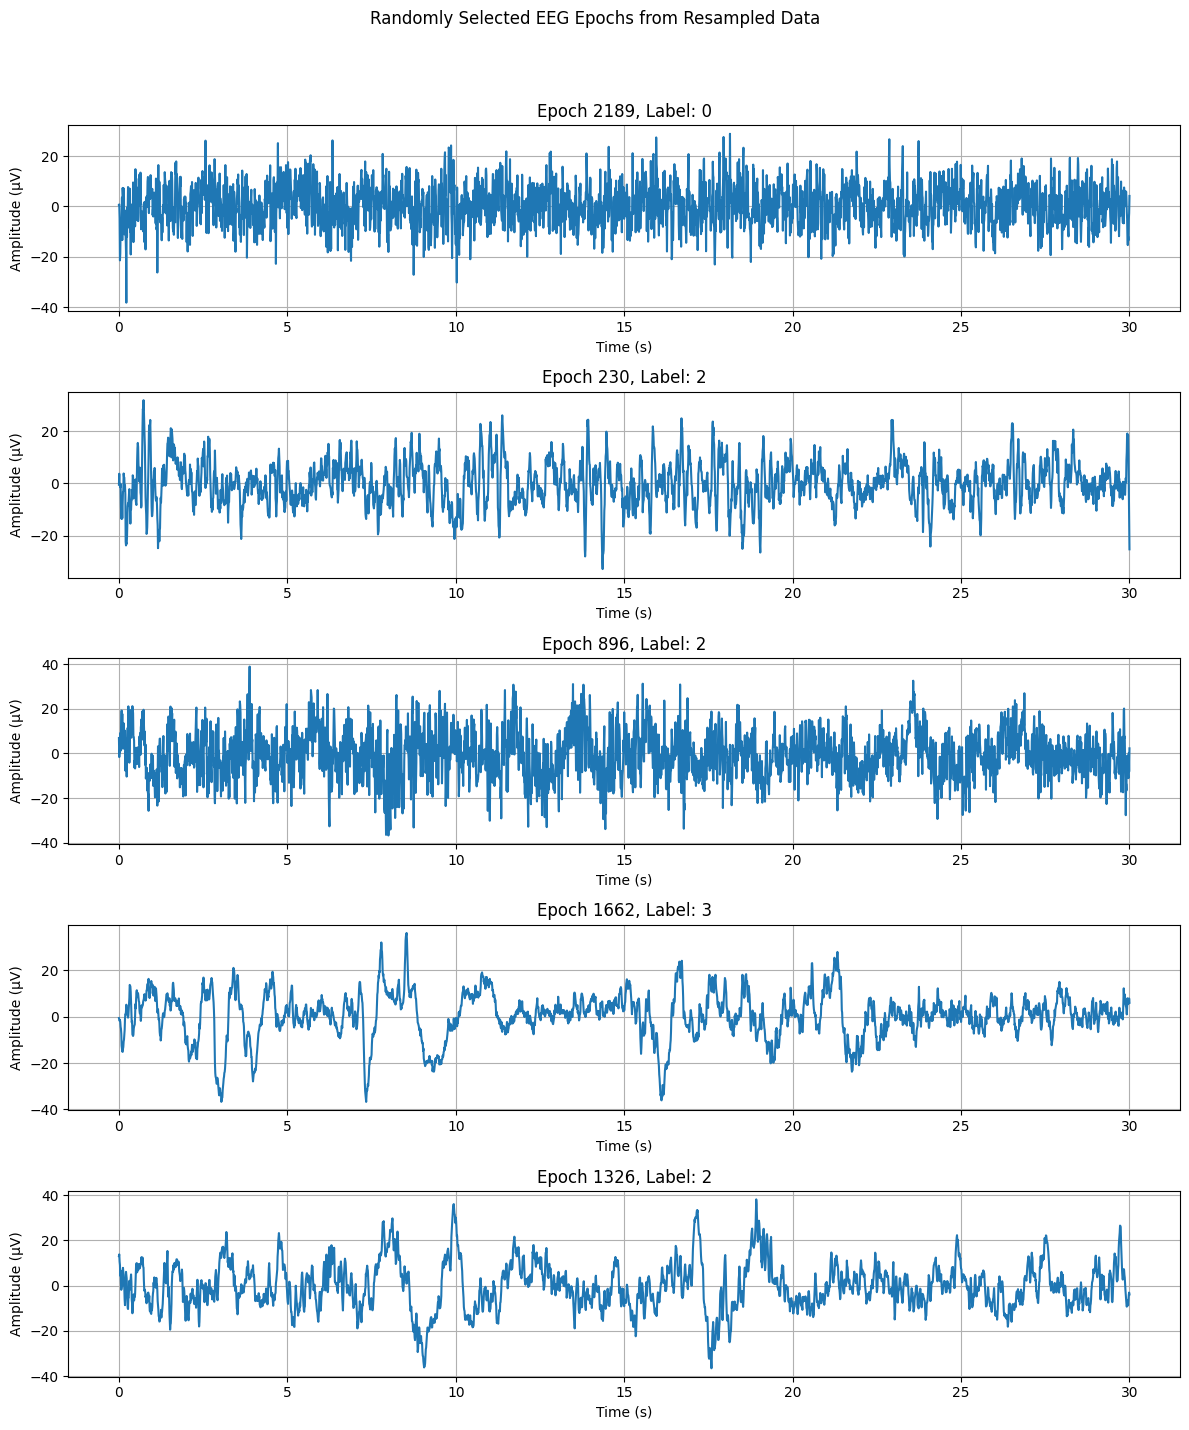

Overall mean of X_resampled (µV): -0.7654
Overall std of X_resampled (µV): 13.7799
Number of epochs in X_resampled: 2950
Shape of X_resampled: (2950, 1, 3001)
[0 1 2 ... 4 4 4]


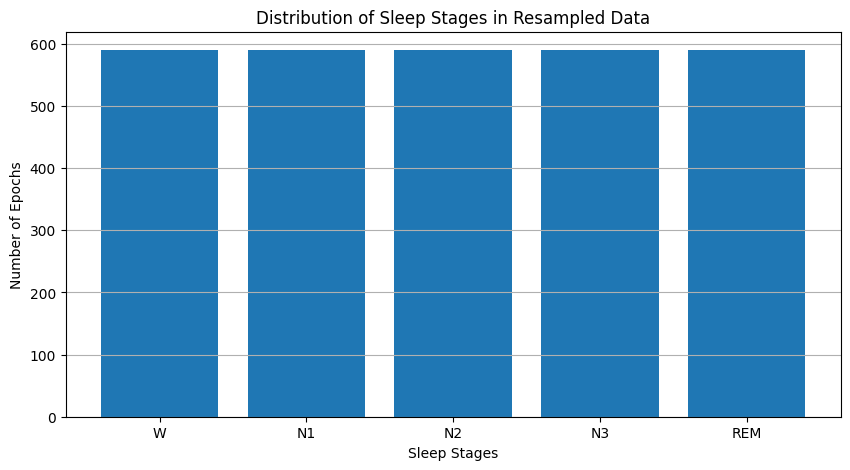

In [2]:
import matplotlib.pyplot as plt
import random
import numpy as np # Ensure numpy is imported
import os


# 假设 X_resampled 是 (n_epochs, 1, n_samples)
# 假设 y_resampled 是 (n_epochs,)
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
train_dir = os.path.join(data_dir, 'train', 'cache')
X_resampled = np.load(os.path.join(train_dir, 'X_resampled.npy'))
y_resampled = np.load(os.path.join(train_dir, 'y_resampled.npy'))


num_epochs_to_plot = 5 # 随机选择5个epoch进行绘制

fig, axes = plt.subplots(num_epochs_to_plot, 1, figsize=(12, num_epochs_to_plot * 3))
fig.suptitle('Randomly Selected EEG Epochs from Resampled Data')

for i in range(num_epochs_to_plot):
    idx = random.randint(0, X_resampled.shape[0] - 1)
    # 假设 epoch_data 是伏特，转换为微伏
    epoch_data = X_resampled[idx, 0, :] * 1e6 # 乘以 10^6 转换为微伏
    label = y_resampled[idx]

    t = np.arange(0, len(epoch_data)) / 100 # 100 Hz 采样率
    axes[i].plot(t, epoch_data)
    axes[i].set_title(f'Epoch {idx}, Label: {label}')
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('Amplitude (µV)') # Y轴标签现在是正确的微伏
    axes[i].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 重新运行 PSD 统计时，注意原始数据的单位
# 如果 X_resampled 仍然是伏特，那么 mean/std 也应该在伏特范围内
# 若看到微伏的统计量，可以在计算前乘以 1e6
print(f"Overall mean of X_resampled (µV): {np.mean(X_resampled * 1e6):.4f}")
print(f"Overall std of X_resampled (µV): {np.std(X_resampled * 1e6):.4f}")

# 对于 PSD，Y轴为 µV²/Hz。
# welch 是对伏特数据 x 运行的，那么 psd 的单位是 V²/Hz。
# 要转换为 µV²/Hz，需要乘以 (1e6)^2 = 1e12
# frequencies, psd = welch(sample_epoch * 1e6, fs=fs, nperseg=fs*4, average='median')
# 或者:
# frequencies, computed_psd_in_V2_Hz = welch(sample_epoch, fs=fs, nperseg=fs*4, average='median')
# psd_in_uV2_Hz = computed_psd_in_V2_Hz * (1e6)**2

# X_resampled 的数量
print(f"Number of epochs in X_resampled: {X_resampled.shape[0]}")

# X_resampled 的形状
print(f"Shape of X_resampled: {X_resampled.shape}")

print(y_resampled)

# 可视化y_resampled
plt.figure(figsize=(10, 5))
plt.hist(y_resampled, bins=np.arange(-0.5, 5.5,
            1), align='mid', rwidth=0.8)
plt.xticks(range(5), ['W', 'N1', 'N2', 'N3', 'REM'])
plt.xlabel('Sleep Stages')
plt.ylabel('Number of Epochs')
plt.title('Distribution of Sleep Stages in Resampled Data')
plt.grid(axis='y')
plt.show()



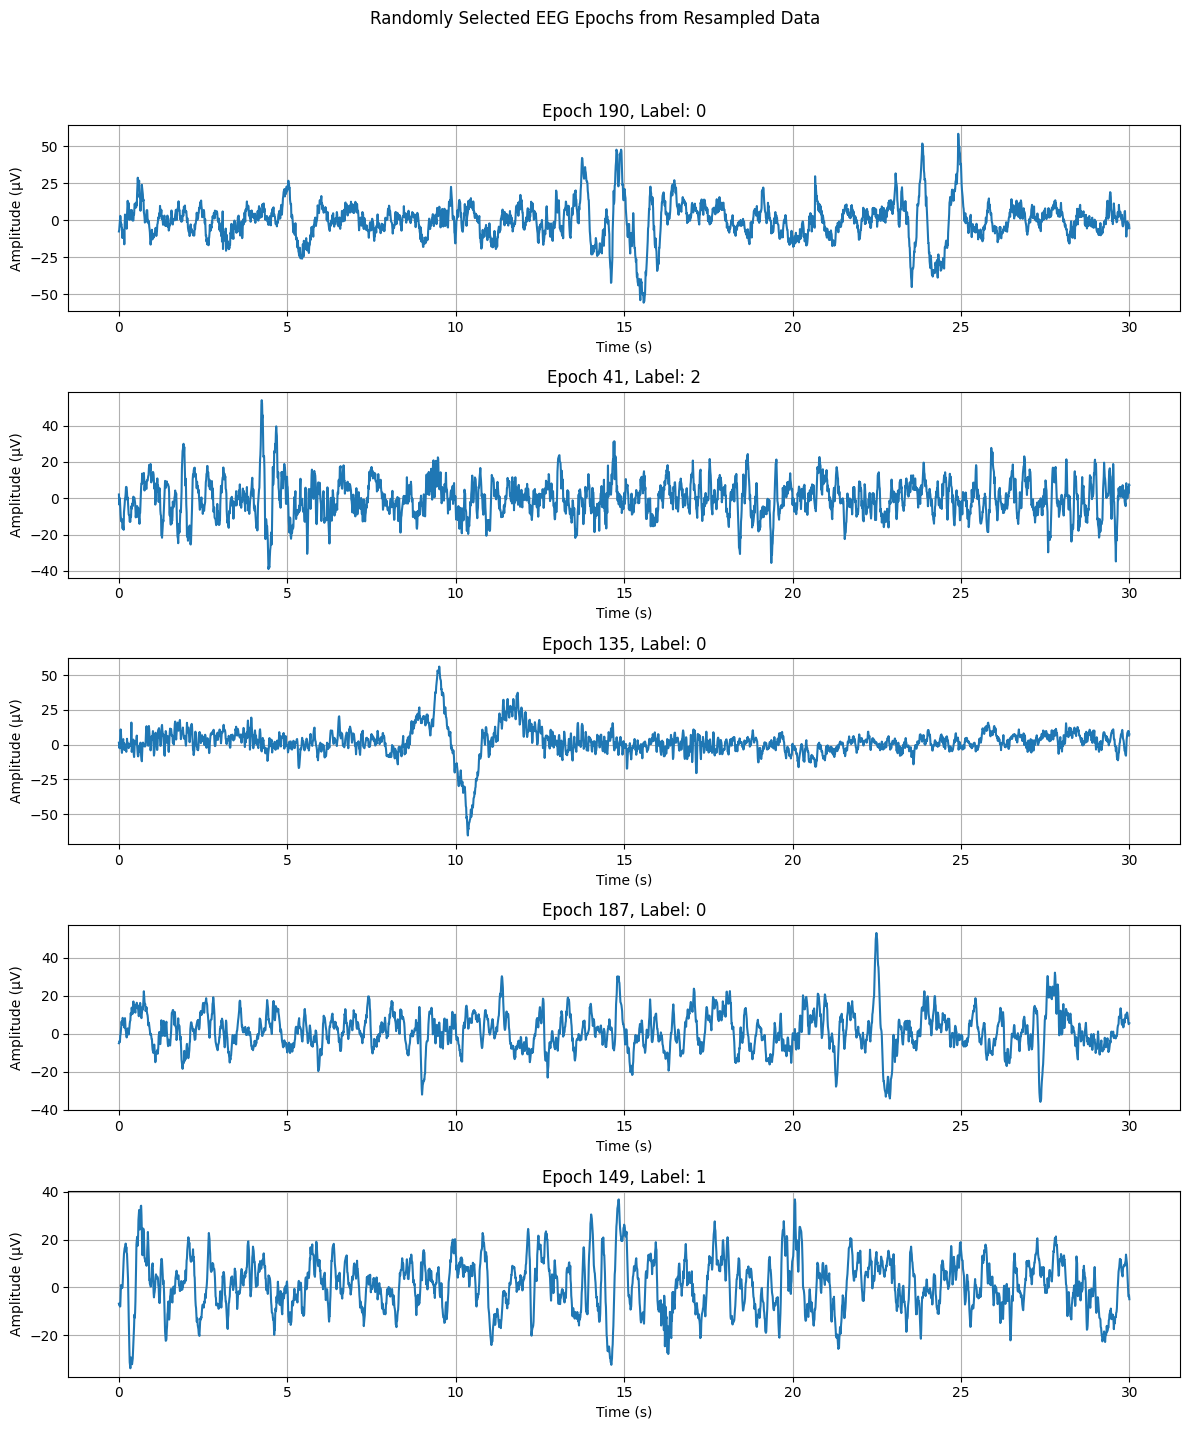

Overall mean of X_resampled (µV): 0.3033
Overall std of X_resampled (µV): 12.2888
Number of epochs in X_resampled: 265
[3 3 3 3 3 3 2 3 2 4 3 3 3 3 3 3 3 3 3 3 2 0 1 2 3 1 2 3 2 3 2 4 1 2 1 0 1
 2 1 0 1 2 1 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 1 0 1 2 0 2 0 1 0 1 2 3
 2 3 2 3 2 3 2 3 2 3 2 1 2 3 3 2 3 2 3 3 2 3 0 1 0 1 0 2 3 2 3 2 0 1 2 1 2
 1 2 3 1 0 1 2 1 1 2 0 1 2 1 0 1 2 4 1 1 0 0 1 1 0 1 0 1 0 1 0 1 0 1 1 0 1
 0 1 0 1 0 1 0 1 0 1 0 1 0 1 2 1 2 0 1 2 3 2 2 2 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4]


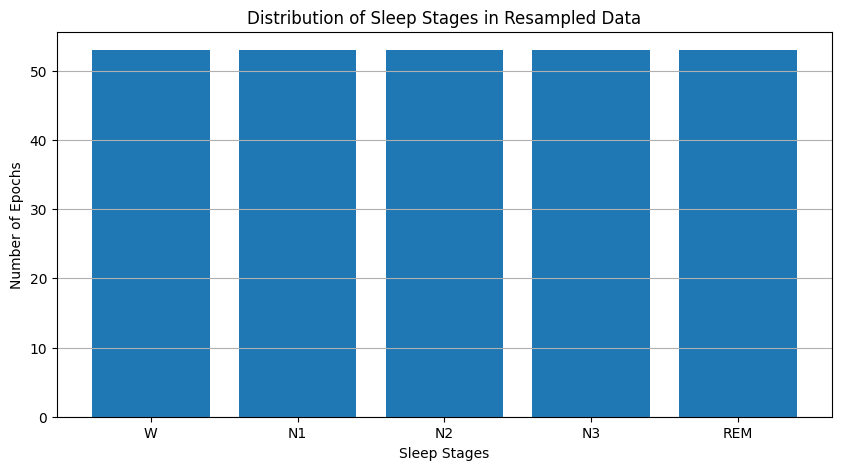

In [3]:
import matplotlib.pyplot as plt
import random
import numpy as np # Ensure numpy is imported
import os


# 假设 X_resampled 是 (n_epochs, 1, n_samples)
# 假设 y_resampled 是 (n_epochs,)
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
train_dir = os.path.join(data_dir, 'val', 'cache')
X_resampled = np.load(os.path.join(train_dir, 'X_resampled.npy'))
y_resampled = np.load(os.path.join(train_dir, 'y_resampled.npy'))


num_epochs_to_plot = 5 # 随机选择5个epoch进行绘制

fig, axes = plt.subplots(num_epochs_to_plot, 1, figsize=(12, num_epochs_to_plot * 3))
fig.suptitle('Randomly Selected EEG Epochs from Resampled Data')

for i in range(num_epochs_to_plot):
    idx = random.randint(0, X_resampled.shape[0] - 1)
    # 假设 epoch_data 是伏特，转换为微伏
    epoch_data = X_resampled[idx, 0, :] * 1e6 # 乘以 10^6 转换为微伏
    label = y_resampled[idx]

    t = np.arange(0, len(epoch_data)) / 100 # 100 Hz 采样率
    axes[i].plot(t, epoch_data)
    axes[i].set_title(f'Epoch {idx}, Label: {label}')
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('Amplitude (µV)') # Y轴标签现在是正确的微伏
    axes[i].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 重新运行 PSD 统计时，注意原始数据的单位
# 如果 X_resampled 仍然是伏特，那么 mean/std 也应该在伏特范围内
# 若看到微伏的统计量，可以在计算前乘以 1e6
print(f"Overall mean of X_resampled (µV): {np.mean(X_resampled * 1e6):.4f}")
print(f"Overall std of X_resampled (µV): {np.std(X_resampled * 1e6):.4f}")

# 对于 PSD，Y轴为 µV²/Hz。
# welch 是对伏特数据 x 运行的，那么 psd 的单位是 V²/Hz。
# 要转换为 µV²/Hz，需要乘以 (1e6)^2 = 1e12
# frequencies, psd = welch(sample_epoch * 1e6, fs=fs, nperseg=fs*4, average='median')
# 或者:
# frequencies, computed_psd_in_V2_Hz = welch(sample_epoch, fs=fs, nperseg=fs*4, average='median')
# psd_in_uV2_Hz = computed_psd_in_V2_Hz * (1e6)**2

# X_resampled 的数量
print(f"Number of epochs in X_resampled: {X_resampled.shape[0]}")

print(y_resampled)

# 可视化y_resampled
plt.figure(figsize=(10, 5))
plt.hist(y_resampled, bins=np.arange(-0.5, 5.5,
            1), align='mid', rwidth=0.8)
plt.xticks(range(5), ['W', 'N1', 'N2', 'N3', 'REM'])
plt.xlabel('Sleep Stages')
plt.ylabel('Number of Epochs')
plt.title('Distribution of Sleep Stages in Resampled Data')
plt.grid(axis='y')
plt.show()



In [4]:
import pandas as pd

def analyze_patient_quality(folder_path):
    """
    分析所有患者的质量指标
    """
    cache_dir = os.path.join(folder_path, 'cache')
    patient_files = glob.glob(os.path.join(cache_dir, '*_y.npy'))
    
    quality_records = []
    
    for y_file in patient_files:
        patient_id = os.path.basename(y_file).replace('_y.npy', '')
        y = np.load(y_file)
        
        counts = Counter(y)
        total = len(y)
        
        # 计算各类别比例
        w_ratio = counts[0] / total
        n1_ratio = counts[1] / total
        n2_ratio = counts[2] / total
        n3_ratio = counts[3] / total
        rem_ratio = counts[4] / total
        unknown_ratio = counts.get(-1, 0) / total
        
        # 质量指标
        record = {
            'patient_id': patient_id,
            'total_epochs': total,
            'W%': w_ratio * 100,
            'N1%': n1_ratio * 100,
            'N2%': n2_ratio * 100,
            'N3%': n3_ratio * 100,
            'REM%': rem_ratio * 100,
            'Unknown%': unknown_ratio * 100,
            'N1/N2_ratio': n1_ratio / (n2_ratio + 1e-8),
        }
        
        quality_records.append(record)
    
    df = pd.DataFrame(quality_records)
    return df

# 运行分析
train_df = analyze_patient_quality('./sleep-edf/data/train')
val_df = analyze_patient_quality('./sleep-edf/data/val')

print("=== 训练集患者质量统计 ===")
print(train_df.describe())
print("\n异常患者（N1/N2 比例 > 0.5）:")
print(train_df[train_df['N1/N2_ratio'] > 0.5][['patient_id', 'N1%', 'N2%', 'N1/N2_ratio']])

print("\n=== 验证集患者质量统计 ===")
print(val_df.describe())
print("\n异常患者:")
print(val_df[val_df['N1/N2_ratio'] > 0.5][['patient_id', 'N1%', 'N2%', 'N1/N2_ratio']])


=== 训练集患者质量统计 ===
       total_epochs          W%         N1%         N2%         N3%  \
count    122.000000  122.000000  122.000000  122.000000  122.000000   
mean     117.229508   12.896374   30.557731   32.093972   15.723333   
std       51.669450    8.010667   10.336256    7.819332   12.824728   
min       29.000000    0.000000    8.130081    7.058824    0.000000   
25%       83.500000    6.717557   23.576424   27.166822    3.026759   
50%      108.000000   10.868533   30.598776   31.866538   14.691927   
75%      147.750000   18.162226   37.717471   37.142857   25.060347   
max      351.000000   35.164835   58.823529   51.724138   51.231527   

             REM%    Unknown%  N1/N2_ratio  
count  122.000000  122.000000   122.000000  
mean     8.610218    0.118371     1.097476  
std      5.085333    0.601846     0.854173  
min      1.052632    0.000000     0.196078  
25%      4.890064    0.000000     0.623968  
50%      7.377177    0.000000     0.973920  
75%     10.958980    0.0000

### 整理文件结构

(脚本)

In [5]:
import os
import shutil

# 根目录路径
base_path = os.path.join(os.getcwd(), 'sleep-edf', 'data')
# 需要处理的子阶段
stages = ['train', 'val']
# 新文件夹的名称
target_folder_name = 'patient_data'

for stage in stages:
    # 构建 cache 文件夹的完整路径
    cache_dir = os.path.join(base_path, stage, 'cache')
    
    # 检查 cache 目录是否存在
    if not os.path.exists(cache_dir):
        print(f"跳过：找不到路径 {cache_dir}")
        continue
    
    # 创建目标文件夹 (如果不存在)
    target_dir = os.path.join(cache_dir, target_folder_name)
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
        print(f"已创建目录: {target_dir}")

    # 遍历 cache 目录下的文件
    for filename in os.listdir(cache_dir):
        # 筛选以 'SC' 开头的文件
        if filename.startswith('SC'):
            source_file = os.path.join(cache_dir, filename)
            target_file = os.path.join(target_dir, filename)
            
            # 移动文件
            shutil.move(source_file, target_file)
            print(f"已移动: {filename} -> {target_folder_name}/")

print("整理完成！")


已创建目录: d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache\patient_data
已移动: SC4001_X.npy -> patient_data/
已移动: SC4001_y.npy -> patient_data/
已移动: SC4011_X.npy -> patient_data/
已移动: SC4011_y.npy -> patient_data/
已移动: SC4012_X.npy -> patient_data/
已移动: SC4012_y.npy -> patient_data/
已移动: SC4021_X.npy -> patient_data/
已移动: SC4021_y.npy -> patient_data/
已移动: SC4022_X.npy -> patient_data/
已移动: SC4022_y.npy -> patient_data/
已移动: SC4042_X.npy -> patient_data/
已移动: SC4042_y.npy -> patient_data/
已移动: SC4051_X.npy -> patient_data/
已移动: SC4051_y.npy -> patient_data/
已移动: SC4052_X.npy -> patient_data/
已移动: SC4052_y.npy -> patient_data/
已移动: SC4061_X.npy -> patient_data/
已移动: SC4061_y.npy -> patient_data/
已移动: SC4062_X.npy -> patient_data/
已移动: SC4062_y.npy -> patient_data/
已移动: SC4071_X.npy -> patient_data/
已移动: SC4071_y.npy -> patient_data/
已移动: SC4072_X.npy -> patient_data/
已移动: SC4072_y.npy -> patient_data/
已移动: SC4081_X.npy -> patient_data/
已移动: SC4081_y.npy -> patient_data/
已移动: SC